<a href="https://colab.research.google.com/github/Jingleeeeee/WQD7013_G7_Stats/blob/main/Global%20Air%20Quality%20Index_G7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 - Reproducible Notebook

# WQD7013_G7_Stats
- **Course:** WQD7013 STATISTICS FOR DATA SCIENCE
- **Dataset:** Global Air Quality 2023 (Messy from WAQI786)
- **Group Members:**

| No. | Name | Student ID |
|-----|------|------------|
|1|Nurin Miza Afiqah Binti Andrie Dazlee|s2154141|
|2|Anisah Maisarah Binti Ahmad Nasaruddin|S2121975|
|3|Ng Jing Lee|24215833|
|4|Nur Aliah Natasya|25085928|
|5|Pan Hui Xin|25090880|
|6|Mohd Khairi Bin Yusof|S2191607|

This notebook follows reproducibility rules (no absolute paths).

### This dataset contains global air quality observations:

- **Air quality measurements**: `PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`  
- **Meteorological data**     : `Temperature`, `Humidity`, `Wind Speed`  
- **Location information**    : `City` and `Country`  
- **Temporal data**           : `Date`
- **Column added**            : `AQI_level`, `AQI_Category`, `PM25_Level`, `PM10_Level`, `Year`, `Month`, `Day` and `Temp_Category`

# Setup & Library Imports

We import the core libraries used throughout the notebook for data handling and data manipulation.

In [81]:
# Make sure your dataset is in the same folder as this notebook
#Core
import pandas as pd
import numpy as np

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Statistics
from scipy import stats
from scipy.stats import skew, kurtosis, chi2_contingency, zscore, norm

#Dataset path
file_path = 'global_air_quality.csv'
kaggle_source = 'https://www.kaggle.com/datasets/coffxc12/global-air-quality-2023-messy-from-waqi786/data'

#Formating
pd.options.display.float_format = '{:.3f}'.format


---
# Task A Dataset Audit and Variable Classification

### A1.1 Load Dataset

In [82]:
# Load the raw dataset
df_raw = pd.read_csv("global_air_quality.csv")
print(f"Dataset loaded successfully! Shape: {df_raw.shape}")

#Create a clean dataset
df_clean = df_raw.copy()

Dataset loaded successfully! Shape: (30450, 12)


In [83]:
df_raw.head()

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
0,Johannesburg,South Africa,4/10/2023,127.510,175.100,NaN,13.020,1.700,196.410,27.460,51.140,10.260
1,Istanbul,Turkey,4/22/2023,93.840,34.190,79.490,44.540,5.180,183.620,10.580,30.480,14.450
2,Berlin,Germany,10/27/2023,52.030,181.800,45.050,30.120,0.960,155.610,-4.090,96.900,2.490
3,SYDNEY,Australia,6/10/2023,110.300,NaN,77.440,9.780,6.540,18.980,17.410,64.790,12.770
4,Dubai,UAE,7/23/2023,120.240,48.980,98.820,6.270,6.980,133.940,13.110,31.610,5.000


**What we found:**
> The csv file loads as expected with a datasets contains 30450 rows × 12 columns that satisfying the minimum size requirement for our analysis and matching the Kaggle dataset description.

### A1.2 Data Types

In [84]:
df_raw.dtypes

City            object
Country         object
Date            object
PM2.5          float64
PM10           float64
NO2            float64
SO2            float64
CO             float64
O3             float64
Temperature    float64
Humidity       float64
Wind Speed     float64
dtype: object

**Justification for A1.2:**
- Categorical variables such as `country_name`,`city_name` and `Date` are stored as `object` types.
- Numerical variables such as pollutant concentrations (e.g., `PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`, `Temperature`, `Humidity`, `Wind Speed`) are stored as numeric types `float64`.

### A1.3 Missing Value

In [85]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100

pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct
})

,Missing Count,Missing %
City,0,0.000
Country,0,0.000
Date,0,0.000
PM2.5,1552,5.097
PM10,1561,5.126
NO2,1593,5.232
SO2,1475,4.844
CO,1496,4.913
O3,1600,5.255
Temperature,0,0.000


**What we found:**
- Missing values were assessed for each column.

- Columns such as `PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3` contain  missing values.

### A1.4 Duplicate Rows

In [86]:
duplicate_count = df_raw.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 10495


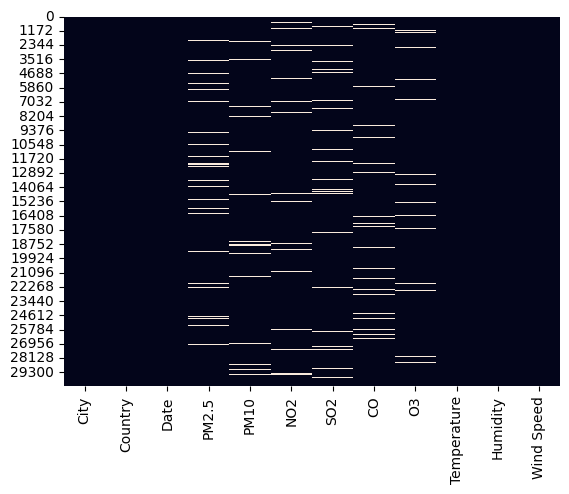

In [87]:
sns.heatmap(df_raw.isnull(), cbar=False)
plt.show()

**What we found:**
- A total of 10495 duplicate rows were identified in the dataset.

### A1.5 Column with Wrong Inferred dtype

In [88]:
# Convert to table format
wrong_dtype = df_raw[["City", "Country", "Date"]].dtypes.reset_index()
wrong_dtype.columns = ["Column", "Inferred dtype"]

wrong_dtype

,Column,Inferred dtype
0,City,object
1,Country,object
2,Date,object


### Justification for A1.5
The following columns `City`, `Country`, and `Date`were identified as having incorrect inferred data types and require conversion to ensure accurate and efficient analysis.


### A1.6 Column with Corrected inferred dtype for Variable Classification purpose

#### Issue 1: Incorrect Data Type for Date
- The `Date` variable is stored as an object instead of a datetime type.
- This prevents proper time-based analysis and must be corrected.

In [89]:
#Correct the data type for data
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce") # errors="coerce" to safe handling any invalid dates
#Show before and after
print("Before:", df_raw["Date"].dtype)
print("After :", df_clean["Date"].dtype)

Before: object
After : datetime64[ns]


In [90]:
#Check
df_clean["Date"].isna().sum()

np.int64(0)

In [91]:
df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Day"] = df_clean["Date"].dt.day

#Show the cleaned output for date
df_clean[["Date", "Year", "Month", "Day"]].head()

,Date,Year,Month,Day
0,2023-04-10,2023,4,10
1,2023-04-22,2023,4,22
2,2023-10-27,2023,10,27
3,2023-06-10,2023,6,10
4,2023-07-23,2023,7,23


#### After Conversion
- The `Date` variable was initially stored as an `object` dtype.
- It was converted to datetime format using `pd.to_datetime()` to enable chronological analysis such as `Year`, `Month`, and`Day`.
- No missing or invalid date values were detected which indicating that no significant conversion errors and can proceed for variable classification.

#### Issue 2: Data Type Improvement for `City` and `Country`
- The `City` and `Country` variables are stored as an object instead of a category type.
- While this is acceptable for string data, they were converted to categorical types to improve memory efficiency and better reflect their nominal categorical nature.

In [92]:
df_clean["City"] = df_clean["City"].astype("category")
df_clean["Country"] = df_clean["Country"].astype("category")
df_clean[["City", "Country"]].dtypes

City       category
Country    category
dtype: object

#### After Conversion
- The `City` and `Country` variables were converted from `object` to `categorical` dtype to improve memory efficiency and better reflect their nominal categorical nature.
- The conversion was successful, and variable classification can proceed.

---
## A2 Variable Classification

### A2.1 Additional Variable Transformations

#### Issue 3: Negative Temperature Values
- The `Temperature` variable includes negative values.
- While negative temperatures are valid in some geographic regions, they may be unrealistic depending on the dataset's location and context.
- These values should be verified to ensure they are not data entry errors or unit inconsistencies (e.g., Celsius vs Kelvin).

In [93]:
#Check negative temperature
df_raw[df_raw["Temperature"] < 0]

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
2,Berlin,Germany,10/27/2023,52.030,181.800,45.050,30.120,0.960,155.610,-4.090,96.900,2.490
5,Johannesburg,South Africa,7/25/2023,119.390,148.610,38.320,21.480,1.790,96.780,-2.620,89.280,9.270
14,London,UK,3/23/2023,21.330,190.160,26.620,40.190,2.630,14.070,-8.780,44.950,2.390
15,Seoul,South Korea,6/5/2023,79.710,195.270,91.260,NaN,1.240,NaN,-6.260,58.000,1.090
17,Beijing,China,4/3/2023,105.580,148.880,95.050,39.390,2.380,170.410,-5.820,29.380,13.340
...,...,...,...,...,...,...,...,...,...,...,...,...
30421,Los Angeles,USA,9/1/2023,64.880,173.950,73.250,NaN,9.190,192.190,-3.570,47.090,6.230
30427,NEW YORK,USA,11/26/2023,105.260,62.740,17.200,44.340,1.040,49.280,-4.520,82.350,11.780
30429,Berlin,Germany,7/14/2023,141.170,173.070,21.120,28.460,1.880,183.970,-5.970,11.950,13.200
30430,Sydney,Australia,8/12/2023,59.760,74.140,39.800,25.540,7.720,NaN,-1.260,12.270,17.070


In [94]:
# Define classification functions for temperature
def temp_category(temp):
    if temp < 10:
        return "Cold"
    elif temp <= 28:
        return "Neutral"
    else:
        return "Hot"

df_clean["Temp_Category"] = df_clean["Temperature"].apply(temp_category)

#Clean view
df_clean["Temp_Category"] = pd.Categorical(
    df_clean["Temp_Category"],
    categories=["Cold", "Neutral", "Hot"],
    ordered=True
)

#Show result
df_clean[["Temperature", "Temp_Category"]].head()

#View result
[
    df_clean[["Temperature", "Temp_Category"]].head(),
    df_clean["Temp_Category"].value_counts()
]

[   Temperature Temp_Category
 0       27.460       Neutral
 1       10.580       Neutral
 2       -4.090          Cold
 3       17.410       Neutral
 4       13.110       Neutral,
 Temp_Category
 Cold       12325
 Neutral    10936
 Hot         7189
 Name: count, dtype: int64]

In [95]:
# Determmine the temperature type
df_clean["Temperature"].describe()

count   30450.000
mean       14.801
std        14.487
min       -10.000
25%         2.020
50%        14.660
75%        27.230
max        40.000
Name: Temperature, dtype: float64

#### Justification for Issue 3:
- Negative temperature values were identified and retained because it may represent valid observations depending on the geographic context.
- Instead to removing the negative values, we created a `Temp_Category` with 3 different thresholds, such as `Hot`,`Cold`, and `Neutral` to support our data analysis.
- The descriptive statistics show the temperature values range from -10 to 40, which looks realistic for everyday weather conditions in Celsius.
- Since there are negative values, this also confirms that the data is **NOT** recorded in Kelvin as it represented an absolute scale.

#### Issue 4: Lack of AQI Category Classification
- The dataset does not include categorical air quality classifications (e.g., “Good”, “Moderate”, “Unhealthy”) for pollutant variables such as `PM2.5` and `PM10`.
- Without defined thresholds, it is not possible to directly interpret air quality levels.
- For meaningful analysis, standard AQI breakpoints should be applied to derive categorical variables that enabling better interpretation and comparison.

In [96]:
#Step 1: Define classification functions for both AQI
def classify_pm25(pm25):
    if pm25 <= 5:
        return 1
    elif pm25 <= 15:
        return 2
    elif pm25 <= 25:
        return 3
    elif pm25 <= 50:
        return 4
    elif pm25 <= 100:
        return 5
    else:
        return 6

def classify_pm10(pm10):
    if pm10 <= 15:
        return 1
    elif pm10 <= 45:
        return 2
    elif pm10 <= 75:
        return 3
    elif pm10 <= 150:
        return 4
    elif pm10 <= 250:
        return 5
    else:
        return 6


#Step 2: Apply classification
df_clean["PM25_Level"] = df_clean["PM2.5"].apply(classify_pm25)
df_clean["PM10_Level"] = df_clean["PM10"].apply(classify_pm10)


#Step 3: Combine (with worst cases)
df_clean["AQI_Level"] = df_clean[["PM25_Level", "PM10_Level"]].max(axis=1)


#Step 4: Map to category labels
labels = {
    1: "Very Good",
    2: "Good",
    3: "Moderate",
    4: "Unhealthy",
    5: "Very Unhealthy",
    6: "Hazardous"
}
df_clean["AQI_Category"] = df_clean["AQI_Level"].map(labels)

#Step 5: Change type from object to category as ordinal order
df_clean["AQI_Category"] = pd.Categorical(
    df_clean["AQI_Category"],
    categories=[
        "Very Good",
        "Good",
        "Moderate",
        "Unhealthy",
        "Very Unhealthy",
        "Hazardous"
    ],
    ordered=True
)
#Step 5: View result
[
    df_clean[["PM2.5", "PM10", "AQI_Category"]].head(),
    df_clean["AQI_Category"].value_counts()
]

[    PM2.5    PM10    AQI_Category
 0 127.510 175.100       Hazardous
 1  93.840  34.190  Very Unhealthy
 2  52.030 181.800  Very Unhealthy
 3 110.300     NaN       Hazardous
 4 120.240  48.980       Hazardous,
 AQI_Category
 Hazardous         12649
 Very Unhealthy    11515
 Unhealthy          4914
 Moderate           1015
 Good                357
 Very Good             0
 Name: count, dtype: int64]

#### Justification for Issue 4:
> A categorical AQI variable was created from PM2.5 values using standard thresholds to improve interpretability.
- Air quality categories `AQI_Category` were derived using both `PM2.5` and `PM10` concentrations based on thresholds aligned with the WHO Air Quality Guidelines.
- Each pollutant was first classified into risk levels such as `Very Good`,`Good`, `Moderate`, `Unhealthy`, `Very Unhealthy`, `Hazardous`  and the overall air quality category was determined using the maximum (worst case) level.
- This approach corresponds to real-world air quality assessment practices, in which the most hazardous pollutant determines overall risk.
- The outcome categories offer a more complete and health-related assessment of air quality conditions.

### A2.2 Classification Table

In [97]:
# Step 1: Create classification table
classification = pd.DataFrame({
    "Variable": [
        "City", "Country", "Date",
        "PM2.5", "PM10", "NO2", "SO2", "CO", "O3",
        "Temperature", "Humidity", "Wind Speed",
        "PM25_Level", "PM10_Level", "AQI_Level", "AQI_Category",
        "Year", "Month", "Day"
    ],

    "Measurement Type": [
        "Nominal categorical", "Nominal categorical", "Continuous (temporal)",
        "Continuous numerical", "Continuous numerical", "Continuous numerical", "Continuous numerical", "Continuous numerical", "Continuous numerical",
        "Continuous numerical", "Continuous numerical", "Continuous numerical",
        "Ordinal categorical", "Ordinal categorical", "Ordinal categorical", "Ordinal categorical",
        "Discrete numerical", "Discrete numerical", "Discrete numerical"
    ],

    "Role": [
        "Identifier", "Identifier", "Feature",
        "Feature", "Feature", "Feature", "Feature", "Feature", "Feature",
        "Feature", "Feature", "Feature",
        "Derived", "Derived", "Derived", "Derived",
        "Derived", "Derived", "Derived"
    ],

    "Summary Statistic": [
        "Mode", "Mode", "Min/Max",
        "Mean/Median", "Mean/Median", "Mean/Median", "Mean/Median", "Mean/Median", "Mean/Median",
        "Mean/Median", "Mean/Median", "Mean/Median",
        "Frequency", "Frequency", "Frequency", "Frequency",
        "Mode", "Mode", "Mode"
    ],

    "Visualisation": [
        "Bar chart", "Bar chart", "Line plot",
        "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot",
        "Histogram/Boxplot", "Histogram/Boxplot", "Histogram/Boxplot",
        "Bar chart", "Bar chart", "Bar chart", "Bar chart",
        "Bar chart", "Bar chart", "Bar chart"
    ]
})

# Step 2: Add Pandas dtype automatically
classification["Pandas dtype"] = df_clean[classification["Variable"]].dtypes.values

# Step 3: Reorder columns
classification = classification[
    ["Variable", "Pandas dtype", "Measurement Type", "Role", "Summary Statistic", "Visualisation"]
]

# Step 4: Display
classification.style.set_caption("Variable Classification Table")

,Variable,Pandas dtype,Measurement Type,Role,Summary Statistic,Visualisation
0,City,category,Nominal categorical,Identifier,Mode,Bar chart
1,Country,category,Nominal categorical,Identifier,Mode,Bar chart
2,Date,datetime64[ns],Continuous (temporal),Feature,Min/Max,Line plot
3,PM2.5,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
4,PM10,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
5,NO2,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
6,SO2,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
7,CO,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
8,O3,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot
9,Temperature,float64,Continuous numerical,Feature,Mean/Median,Histogram/Boxplot


### Justification for A2.2

> Overall, this classification ensures that appropriate statistical methods and visualisations are applied, improving the accuracy and interpretability of the analysis.

---
## A3 Missing Data Diagnosis

### A3.1 Misssing Data Pattern - Numerical summary

In [98]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_pct
})

missing_summary

,Missing Count,Missing %
City,0,0.000
Country,0,0.000
Date,0,0.000
PM2.5,1552,5.097
PM10,1561,5.126
NO2,1593,5.232
SO2,1475,4.844
CO,1496,4.913
O3,1600,5.255
Temperature,0,0.000


### Justification for A3.1 ###
- Missing data analysis shows that pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`) contain approximately 4.8% to 5.3% missing values, while the remaining variables have no missing observations.

### A3.2 Visualization - Missing Data Pattern

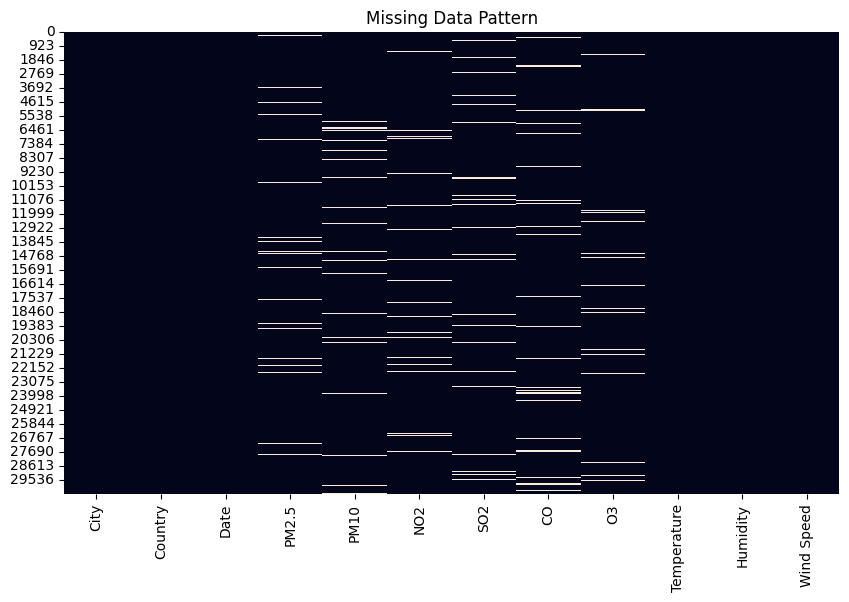

In [99]:
plt.figure(figsize=(10,6))
sns.heatmap(df_raw.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

#### What we found ####
- The heatmap shows that missing values are primarily concentrated within the air pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, and `O3`), while other variables such as `Temperature`, `Humidity`, and `Wind Speed` remain complete.

- The missing values appear as scattered gaps across different observations rather than forming large continuous blocks, and the missing values do not follow any obvious pattern.

- Overall, the pattern is more consistent with **Missing at Random (MAR)**.

### A3.3 Classify missingness (MCAR / MAR / MNAR)

In [100]:
print("Missing < 5% (excluding 0):")
print(missing_summary[(missing_summary["Missing %"] > 0) & (missing_summary["Missing %"] < 5)])

print("\nMissing ≥ 5%:")
print(missing_summary[missing_summary["Missing %"] >= 5])

Missing < 5% (excluding 0):
     Missing Count  Missing %
SO2           1475      4.844
CO            1496      4.913

Missing ≥ 5%:
       Missing Count  Missing %
PM2.5           1552      5.097
PM10            1561      5.126
NO2             1593      5.232
O3              1600      5.255


#### Justification for A3.3

- The missingness pattern varies across variables and is concentrated in pollutant measurements.
- Variables such as `City`, `Country`, `Date`, `Temperature`, `Humidity`, and `Wind Speed` contain **no missing values** and therefore do not show any missingness mechanism.
- Variables such as `SO2` and `CO` show **less than 5% missing values**.
- `PM2.5`, `PM10`, `NO2`, and `O3` exhibit **more than 5% missing values**.
- The missing values are scattered across observations rather than forming clear or continuous blocks.

### A3.4 Compare handling strategies - for `PM2.5`

In [101]:
# Method 1: Listwise deletion (PM2.5 only)
pm25_drop = df_clean["PM2.5"].dropna()

mean_drop = pm25_drop.mean()
std_drop = pm25_drop.std()

# Method 2: Median imputation (PM2.5 only)
pm25_impute = df_clean["PM2.5"].copy()

median_value = pm25_impute.median()
pm25_impute = pm25_impute.fillna(median_value)

mean_impute = pm25_impute.mean()
std_impute = pm25_impute.std()

# Compare results
print("Listwise Deletion → Mean:", mean_drop, "Std:", std_drop)
print("Median Imputation → Mean:", mean_impute, "Std:", std_impute)

Listwise Deletion → Mean: 77.65102740674094 Std: 42.01175009093977
Median Imputation → Mean: 77.68206600985222 Std: 40.92728736407074


### Justification for A3.4 ###
> The analysis is conducted on the cleaned dataset (df_clean) to ensure consistency after preprocessing.

- Listwise deletion reduces the dataset size and may introduce bias if missingness is not completely random.
- Median imputation preserves all observations and provides a robust estimate of central tendency.
- Both methods produce similar mean values, but median imputation results in a slightly lower standard deviation. This is because imputing with the median reduces variability in the dataset by replacing them with a central value.
- Therefore, median imputation is preferred as it retains all data while providing stable results.

### A3.5 Data Cleaning

#### Good structural quality, but needs to improve
- The dataset demonstrates generally good structural quality and is suitable for statistical analysis.
- It contains a sufficient number of observations and well-defined variables.
- Most numerical variables are correctly typed and key contextual variables such as `City` and `Country` are complete.
- However, several data quality issues are necessary to conduct a data preprossesing before the analysis.

In [102]:
summary_table = pd.DataFrame({
    "Aspect": ["Rows", "Columns", "Duplicate Rows", "Missing Values"],
    "Observation": [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.duplicated().sum(),
        "Present (~5% in pollutant variables)"
    ]
})

summary_table

,Aspect,Observation
0,Rows,30450
1,Columns,12
2,Duplicate Rows,10495
3,Missing Values,Present (~5% in pollutant variables)


### A3.5.1 Key Data Quality Issues

#### Issues 5: Duplicate and Near-Duplicate Rows
- The dataset includes duplicate and near-duplicate observations.
- These duplicates can bias statistical summaries by over-representing certain records.
- Removing duplicate rows is necessary to ensure each observation contributes equally to the analysis.

In [103]:
#Step 1: Count duplicates
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows (excluding first occurrence):", duplicate_count)

Duplicate rows (excluding first occurrence): 10495


In [104]:
# Step 2: Show ALL duplicate rows (both original + repeated)
duplicates_full = df_clean[df_clean.duplicated(keep=False)].copy()
duplicates_full = duplicates_full.sort_values(by=["City", "Date"]).reset_index(drop=True)
duplicates_full["Duplicate Flag"] = "Yes"
duplicates_full.head(10)

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,...,Wind Speed,Year,Month,Day,Temp_Category,PM25_Level,PM10_Level,AQI_Level,AQI_Category,Duplicate Flag
0,BANGKOK,Thailand,2023-03-25,75.500,157.400,79.920,49.200,7.990,77.180,20.770,...,3.140,2023,3,25,Neutral,5,5,5,Very Unhealthy,Yes
1,BANGKOK,Thailand,2023-03-25,75.500,157.400,79.920,49.200,7.990,77.180,20.770,...,3.140,2023,3,25,Neutral,5,5,5,Very Unhealthy,Yes
2,BANGKOK,Thailand,2023-05-07,76.490,114.470,72.370,21.860,0.640,103.550,8.030,...,11.080,2023,5,7,Cold,5,4,5,Very Unhealthy,Yes
3,BANGKOK,Thailand,2023-05-07,76.490,114.470,72.370,21.860,0.640,103.550,8.030,...,11.080,2023,5,7,Cold,5,4,5,Very Unhealthy,Yes
4,BANGKOK,Thailand,2023-06-05,82.040,109.580,97.120,9.640,8.530,46.720,3.030,...,3.350,2023,6,5,Cold,5,4,5,Very Unhealthy,Yes
5,BANGKOK,Thailand,2023-06-05,82.040,109.580,97.120,9.640,8.530,46.720,3.030,...,3.350,2023,6,5,Cold,5,4,5,Very Unhealthy,Yes
6,BANGKOK,Thailand,2023-07-20,27.080,139.490,67.300,10.860,1.610,85.500,21.440,...,19.050,2023,7,20,Neutral,4,4,4,Unhealthy,Yes
7,BANGKOK,Thailand,2023-07-20,27.080,139.490,67.300,10.860,1.610,85.500,21.440,...,19.050,2023,7,20,Neutral,4,4,4,Unhealthy,Yes
8,BANGKOK,Thailand,2023-08-12,148.440,193.880,24.880,7.260,9.120,10.370,36.000,...,11.480,2023,8,12,Hot,6,5,6,Hazardous,Yes
9,BANGKOK,Thailand,2023-08-12,148.440,193.880,24.880,7.260,9.120,10.370,36.000,...,11.480,2023,8,12,Hot,6,5,6,Hazardous,Yes


In [105]:
# Step 3: Remove duplicates
df_clean = df_clean.drop_duplicates()

In [106]:
# Step 4: Verify removal
duplicate_after = df_clean.duplicated().sum()
print("\nDuplicate rows AFTER removal:", duplicate_after)


Duplicate rows AFTER removal: 0


In [107]:
# Step 5: Show dataset shape change
print("\nDataset shape BEFORE:", df_raw.shape)
print("Dataset shape AFTER :", df_clean.shape)


Dataset shape BEFORE: (30450, 12)
Dataset shape AFTER : (19955, 20)


#### After cleaning the duplicate
- A sample of duplicate rows is presented to provide visual evidence of repeated observations within the dataset.
- Displaying both the original and duplicated entries allows verification that the rows are identical across all variables.
- This supports the decision to remove duplicates, as their presence would otherwise bias statistical summaries by over-representing certain observations.
- The table also demonstrates that duplicate detection was performed after standardisation, ensuring that inconsistencies in formatting did not mask near-duplicate records.

#### Issues 6 : Missing Values
- Several pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, and `O3`) contain approximately 5% missing values.
- The missingness appears scattered and is most consistent with **Missing at Random (MAR)**. This level of missingness is moderate and may introduce bias if not handled properly.
- **Median imputation** is preferred due to the skewed distribution of environmental data.

In [108]:
#Median imputation to fill in the missing values
missing_before = df_clean["PM2.5"].isnull().sum()
print("Missing before:", missing_before)

#Assign a list and use for loop
var_to_impute = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

for col in var_to_impute:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

missing_after = df_clean["PM2.5"].isnull().sum()

print("Missing after:", missing_after)

#Result data clean for no missing value
df_clean[var_to_impute].isnull().sum()

Missing before: 1491
Missing after: 0


PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
dtype: int64

#### After median imputation
- Missing values in pollutant variables (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, and `O3`) were handled simultaneously using median imputation.
- This approach ensures consistency across variables and is appropriate given the skewed distribution of environmental data, and is less affected by outliers or extreme values.  

#### Issue 7: Inconsistent Variables Formatting
- Inconsistent formatting is present in variables such as `Country` and `City`, including differences in type, capitalisation, spacing, and naming conventions (e.g., "USA" vs "usa").
- This can lead to incorrect grouping and aggregation.
- Standardisation is required before analysis.

In [109]:
# Standardisation

print("Before unique City:", df_raw["City"].nunique())

df_clean["City"] = df_clean["City"].str.strip().str.lower()

print("After unique City :", df_clean["City"].nunique())

df_clean["City"].value_counts().head(10)

Before unique City: 120
After unique City : 20


City
johannesburg    1071
mumbai          1062
dubai           1049
toronto         1047
berlin          1031
seoul           1027
madrid          1027
cairo           1011
bangkok         1009
sydney          1007
Name: count, dtype: int64

In [110]:
# Before Standardisation for City
list(df_raw["City"].unique())
df_raw["City"].unique().tolist()

['Johannesburg',
 'Istanbul',
 'Berlin',
 'SYDNEY',
 'Dubai',
 'Los Angeles',
 'Mumbai',
 'Beijing',
 'Paris',
 'New York',
 'London',
 'Seoul   ',
 'Toronto',
 'Tokyo',
 'london',
 'Mexico City',
 'Madrid',
 'Seoul',
 'Bangkok',
 'New York   ',
 'Rio de Janeiro',
 'MOSCOW',
 'BERLIN',
 'BANGKOK',
 'Moscow',
 'MADRID',
 'johannesburg',
 'MEXICO CITY',
 'Berlin   ',
 'LONDON',
 'tokyo',
 'Paris   ',
 'berlin',
 'istanbul',
 'Cairo',
 'rio de janeiro',
 'Mexico City   ',
 'bangkok',
 'cairo',
 'dubai',
 'new york',
 'toronto',
 'los angeles',
 'mexico city',
 'RIO DE JANEIRO',
 'BEIJING',
 'Sydney',
 'sydney',
 'ISTANBUL',
 'Beijing   ',
 'CAIRO',
 'MUMBAI',
 'DUBAI',
 'madrid',
 'Sydney   ',
 'NEW YORK   ',
 'beijing',
 'moscow',
 'JOHANNESBURG',
 'Moscow   ',
 'TOKYO',
 'TORONTO',
 'PARIS',
 'LOS ANGELES',
 'SEOUL',
 'Cairo   ',
 'Rio de Janeiro   ',
 'mumbai',
 'new york   ',
 'MUMBAI   ',
 'Bangkok   ',
 'Johannesburg   ',
 'NEW YORK',
 'Los Angeles   ',
 'Madrid   ',
 'paris',
 'Ist

In [111]:
# After Standardisation for City
list(df_clean["City"].unique())
df_clean["City"].unique().tolist()

['johannesburg',
 'istanbul',
 'berlin',
 'sydney',
 'dubai',
 'los angeles',
 'mumbai',
 'beijing',
 'paris',
 'new york',
 'london',
 'seoul',
 'toronto',
 'tokyo',
 'mexico city',
 'madrid',
 'bangkok',
 'rio de janeiro',
 'moscow',
 'cairo']

#### After standardization
- The `City` variable was standardised by removing whitespace and converting text to lowercase, reducing the number of unique categories and ensuring consistent grouping.

---
## A4 Data Quality Narrative

#### Overall Dataset Quality

After going through a structured cleaning and validation process, the dataset can generally be adequate for statistical analysis.

### A4.1 Overview of the Final Cleaned Dataset: `df_clean`

In [112]:
# FINAL CLEANED DATASET (PREVIEW)
df_clean.head()
df_clean.info()

df_clean[[
    "City", "Country", "Date",
    "PM2.5", "PM10",
    "AQI_Category"
]].head
df_clean.head().style.set_caption("Final Cleaned Dataset (Preview)")

<class 'pandas.core.frame.DataFrame'>
Index: 19955 entries, 0 to 30449
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   City           19955 non-null  object        
 1   Country        19955 non-null  category      
 2   Date           19955 non-null  datetime64[ns]
 3   PM2.5          19955 non-null  float64       
 4   PM10           19955 non-null  float64       
 5   NO2            19955 non-null  float64       
 6   SO2            19955 non-null  float64       
 7   CO             19955 non-null  float64       
 8   O3             19955 non-null  float64       
 9   Temperature    19955 non-null  float64       
 10  Humidity       19955 non-null  float64       
 11  Wind Speed     19955 non-null  float64       
 12  Year           19955 non-null  int32         
 13  Month          19955 non-null  int32         
 14  Day            19955 non-null  int32         
 15  Temp_Category  19955 non

,City,Country,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed,Year,Month,Day,Temp_Category,PM25_Level,PM10_Level,AQI_Level,AQI_Category
0,johannesburg,South Africa,2023-04-10 00:00:00,127.510000,175.100000,52.170000,13.020000,1.700000,196.410000,27.460000,51.140000,10.260000,2023,4,10,Neutral,6,5,6,Hazardous
1,istanbul,Turkey,2023-04-22 00:00:00,93.840000,34.190000,79.490000,44.540000,5.180000,183.620000,10.580000,30.480000,14.450000,2023,4,22,Neutral,5,2,5,Very Unhealthy
2,berlin,Germany,2023-10-27 00:00:00,52.030000,181.800000,45.050000,30.120000,0.960000,155.610000,-4.090000,96.900000,2.490000,2023,10,27,Cold,5,5,5,Very Unhealthy
3,sydney,Australia,2023-06-10 00:00:00,110.300000,103.195000,77.440000,9.780000,6.540000,18.980000,17.410000,64.790000,12.770000,2023,6,10,Neutral,6,6,6,Hazardous
4,dubai,UAE,2023-07-23 00:00:00,120.240000,48.980000,98.820000,6.270000,6.980000,133.940000,13.110000,31.610000,5.000000,2023,7,23,Neutral,6,3,6,Hazardous


In [113]:
# Check df_clean shape
print(f"Final cleaned dataset contains {df_clean.shape[0]} rows and {df_clean.shape[1]} columns.")

Final cleaned dataset contains 19955 rows and 20 columns.


### After preprocessing, the dataset `df_clean` is cleaned and ready for descriptive statistical analysis in Task B.

---
# Task B – Descriptive Statistics and Distribution Shape

## B1. Univariate Summaries

This section computes key descriptive statistics for all numerical variables, including measures of central tendency, dispersion, and distribution shape.

We report:
- Mean and median (centre)
- Standard deviation and IQR (spread)
- Min, max, 5th and 95th percentiles (range and tails)
- Skewness and excess kurtosis (shape)

These statistics help determine whether distributions are symmetric, skewed, or heavy-tailed, which directly affects the choice of appropriate summary measures.

In [114]:
# Select numerical columns
num_cols = ["PM2.5", "PM10", "NO2", "SO2", "CO",
    "O3", "Temperature", "Humidity", "Wind Speed"]

summary_list = []

for col in num_cols:
    data = df_clean[col].dropna()

    summary = {
        "Variable": col,
        "Mean": data.mean(),
        "Median": data.median(),
        "Std Dev": data.std(),
        "IQR": data.quantile(0.75) - data.quantile(0.25),
        "Min": data.min(),
        "Max": data.max(),
        "5th Percentile": data.quantile(0.05),
        "95th Percentile": data.quantile(0.95),
        "Skewness": skew(data),
        "Excess Kurtosis": kurtosis(data)
    }

    summary_list.append(summary)

summary_df_clean = pd.DataFrame(summary_list)
summary_df_clean

,Variable,Mean,Median,Std Dev,IQR,Min,Max,5th Percentile,95th Percentile,Skewness,Excess Kurtosis
0,PM2.5,77.764,78.350,40.396,66.560,5.020,149.980,12.620,142.060,-0.023,-1.059
1,PM10,104.178,103.195,52.903,87.350,10.000,200.000,19.630,189.740,0.023,-1.051
2,NO2,52.095,52.170,26.214,43.415,5.010,100.000,9.630,94.760,0.000,-1.032
3,SO2,25.183,25.170,13.533,22.350,1.000,49.990,3.550,47.170,0.019,-1.049
4,CO,5.040,5.080,2.751,4.570,0.100,10.000,0.650,9.450,-0.000,-1.061
5,O3,105.439,105.390,52.868,87.955,10.040,200.000,19.930,190.873,0.002,-1.044
6,Temperature,14.914,14.850,14.454,25.150,-10.000,40.000,-7.550,37.530,0.002,-1.201
7,Humidity,54.753,54.590,25.996,44.865,10.010,99.990,14.507,95.443,0.010,-1.200
8,Wind Speed,10.259,10.330,5.629,9.785,0.500,20.000,1.467,19.030,-0.014,-1.208


### Interpretation:
- **Central Tendency**
  - For all variables, the mean and median are very close (e.g., PM2.5: 77.76 vs 78.35), indicating **approximately symmetric distributions**.
  - This suggests that **extreme values are not heavily distorting the mean**, so both mean and median are reasonable measures of centre.

- **Spread**
  - Variables such as PM10, O3, and PM2.5 show relatively large standard deviations and IQRs, indicating **substantial variability in pollution levels**.
  - Wind Speed and CO have smaller spread, suggesting **more stable measurements**.

- **Skewness**
  - All skewness values are close to 0 (between approximately -0.02 and 0.02), indicating **minimal skewness and near-symmetric distributions**.
  - No variable shows strong right or left skew.

- **Kurtosis**
  - All variables have **negative excess kurtosis (≈ -1)**, indicating **platykurtic distributions** (flatter than normal with lighter tails).
  - This suggests **lighter tails and fewer extreme outliers than expected under a normal distribution**.

- **Outliers and Distribution Shape**
  - The combination of near-zero skewness and negative kurtosis suggests **relatively uniform or evenly spread data**, rather than strongly peaked distributions.
  - Extreme pollution events exist (based on max values), but they are not frequent.

- **Choice of Summary Measures**
  - Given the near symmetry, **mean is an appropriate measure of centre** for most variables.
  - However, due to moderate variability in some variables, **IQR remains a robust measure of spread**, especially for pollution indicators.

- **Practical Insight**
  - Pollution variables (PM2.5, PM10, O3) show **wide ranges**, indicating fluctuating air quality conditions across observations.
  - Environmental factors like temperature and humidity are more **balanced and stable** in comparison.

### Recommendation of Summary Measures:
- For all variables, skewness is near zero and no statistically defined outliers are detected under standard criteria.
- Therefore, the **mean is an appropriate measure of centre** for most variables.

- However, for pollution variables (PM2.5, PM10, O3) with larger variability:
  - The **IQR is preferred as a robust measure of spread**.

- For more stable variables (CO, Wind Speed):
  - **Standard deviation is sufficient** due to lower variability.

## B2. Outlier Investigation

We detect outliers using two methods:
1. IQR fence rule
2. Z-score method (|z| > 3)

We compare the number of outliers detected and examine whether the methods agree.

In [115]:
# Choose two variables
vars_to_check = ["PM2.5", "PM10"]

outlier_results = {}

for col in vars_to_check:
    data = df_clean[col].dropna()

    # IQR method
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_outliers = data[(data < lower) | (data > upper)]

    # Z-score method
    z_scores = np.abs(zscore(data))
    z_outliers = data[z_scores > 3]

    outlier_results[col] = {
        "IQR Outliers": len(iqr_outliers),
        "Z-score Outliers": len(z_outliers),
        "Overlap": len(set(iqr_outliers.index).intersection(set(z_outliers.index)))
    }

pd.DataFrame(outlier_results)

,PM2.5,PM10
IQR Outliers,0,0
Z-score Outliers,0,0
Overlap,0,0


In [116]:
for col in vars_to_check:
    print(f"\nTop 5 highest values for {col}:")
    print(df_clean[col].nlargest(5))


Top 5 highest values for PM2.5:
22504   149.980
26961   149.980
9472    149.960
22435   149.960
2967    149.950
Name: PM2.5, dtype: float64

Top 5 highest values for PM10:
4318   200.000
4407   200.000
3843   199.990
4517   199.990
6550   199.930
Name: PM10, dtype: float64


### Investigation of Extreme Values:
Although neither the IQR method nor the Z-score method detected any formal outliers for PM2.5 and PM10, inspection of the raw data reveals the presence of relatively high values.

- For PM2.5, the highest values are close to 150.
- For PM10, the highest values reach up to 200.

These values are noticeably larger than the central tendency (means ≈ 77.76 and 104.18 respectively), but they are **not flagged as outliers** because:
- They fall within the IQR fences
- Their standardized Z-scores do not exceed the threshold of |z| > 3

This indicates that the dataset has a **wide but well-distributed range**, rather than extreme or isolated spikes.

### Interpretation:
- The absence of detected outliers is consistent with earlier findings:
  - Near-zero skewness → symmetric distributions
  - Negative kurtosis → light tails (few extreme values)

- The high values observed are therefore **plausible observations**, not data errors.

### Conclusion:
- The dataset does not contain statistically extreme outliers under standard definitions.
- Extreme values represent **natural variation in air quality conditions**, rather than anomalies.
- Therefore, **no outlier removal is justified**, as doing so could remove meaningful real-world observations.

## B3. Grouped Comparison

We compare a numerical variable across categories to understand differences in distribution.

Selected:
- Numerical variable: PM2.5
- Categorical variable: AQI_Category

In [117]:
num_var = "PM2.5"
cat_var = "AQI_Category"

order = ["Good",
        "Moderate",
        "Unhealthy",
        "Very Unhealthy",
        "Hazardous"]

grouped_summary = df_clean.groupby("AQI_Category")["PM2.5"].agg(
    Median="median",
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Mean="mean",
    Std="std"
)

grouped_summary.loc[order]

,Median,IQR,Mean,Std
AQI_Category,,,,
Good,9.360,4.745,9.631,2.840
Moderate,17.380,8.460,16.572,5.643
Unhealthy,32.450,19.960,30.786,12.332
Very Unhealthy,68.730,31.750,66.048,23.588
Hazardous,114.880,50.780,109.576,29.876


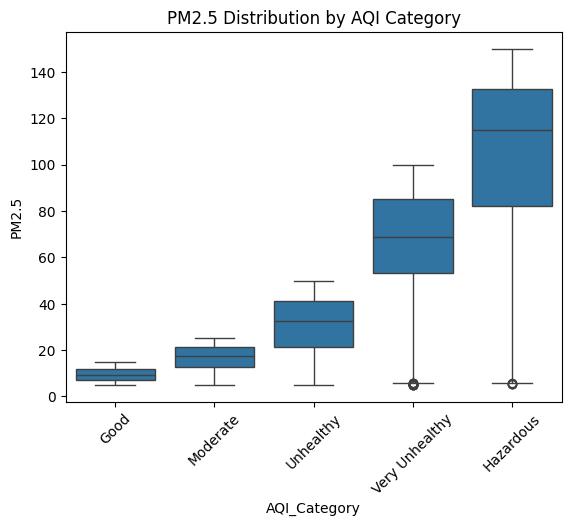

In [118]:
sns.boxplot(data=df_clean,
            x="AQI_Category",
            y="PM2.5",
            order=order)

plt.xticks(rotation=45)
plt.title("PM2.5 Distribution by AQI Category")
plt.show()

### Interpretation of Grouped Comparison:
- There is a clear monotonic increase in PM2.5 levels across AQI categories.
  - Median PM2.5 rises from **9.36 (Good)** to **114.88 (Hazardous)**, indicating progressively worsening air quality.

- **Centre (Median vs Mean):**
  - Median and mean values are very close within each category (e.g., Good: 9.36 vs 9.63), suggesting **approximately symmetric distributions within groups**.
  - This indicates that extreme values are not heavily distorting the central tendency.

- **Spread (IQR and Standard Deviation):**
  - Lower categories (Good, Moderate) show small IQRs (4.75–8.46), indicating **stable and consistent air quality**.
  - Higher categories (Unhealthy to Hazardous) exhibit much larger IQRs (19.96–50.78), reflecting **greater variability in pollution levels**.
  - Standard deviation follows the same pattern, increasing substantially in higher categories.

- **Shape:**
  - Distributions within each category appear roughly symmetric, consistent with earlier findings of near-zero skewness.
  - However, higher categories show **wider dispersion**, indicating increased spread rather than skewness.

- **Outliers:**
  - Very few outliers are visible in the boxplot, supporting earlier findings that the dataset contains **limited extreme values**.

### Justification:
Median is preferred over mean for group comparison because:
- AQI categories have unequal group sizes
- Pollution variability increases in higher categories
- Median is more robust to potential extreme values

Overall, the grouped comparison demonstrates that AQI categorisation accurately reflects both the **level and variability of PM2.5 pollution**, making it a meaningful classification for analysis.

## B4. Correlation and Covariance

We compute the Pearson correlation matrix to assess linear relationships between variables.

In [119]:
# Correlation matrix
corr_matrix = df_clean[num_cols].corr()
corr_matrix

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
PM2.5,1.000,0.016,-0.002,-0.012,0.004,0.010,-0.021,-0.004,0.005
PM10,0.016,1.000,0.006,-0.007,0.008,0.008,0.007,-0.000,0.013
NO2,-0.002,0.006,1.000,0.001,0.006,0.018,-0.020,0.001,0.007
SO2,-0.012,-0.007,0.001,1.000,0.024,-0.004,-0.003,0.001,0.006
CO,0.004,0.008,0.006,0.024,1.000,0.006,-0.020,0.010,-0.011
O3,0.010,0.008,0.018,-0.004,0.006,1.000,0.008,-0.002,-0.016
Temperature,-0.021,0.007,-0.020,-0.003,-0.020,0.008,1.000,0.008,-0.002
Humidity,-0.004,-0.000,0.001,0.001,0.010,-0.002,0.008,1.000,-0.009
Wind Speed,0.005,0.013,0.007,0.006,-0.011,-0.016,-0.002,-0.009,1.000


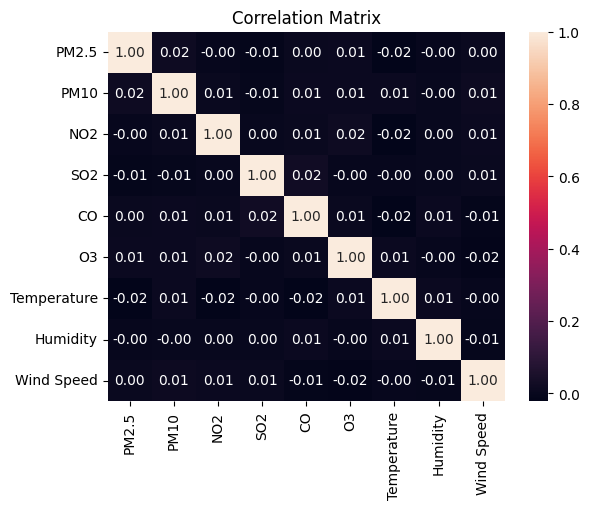

In [120]:
plt.figure()
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [121]:
# Flatten matrix
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Var1", "Var2", "Correlation"]

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs["Var1"] != corr_pairs["Var2"]]

# Sort
sorted_pairs = corr_pairs.sort_values(by="Correlation", ascending=False)

strongest = sorted_pairs.iloc[0]
weakest = sorted_pairs.iloc[-1]

strongest, weakest

(Var1            SO2
 Var2             CO
 Correlation   0.024
 Name: 31, dtype: object,
 Var1           Temperature
 Var2                 PM2.5
 Correlation         -0.021
 Name: 54, dtype: object)

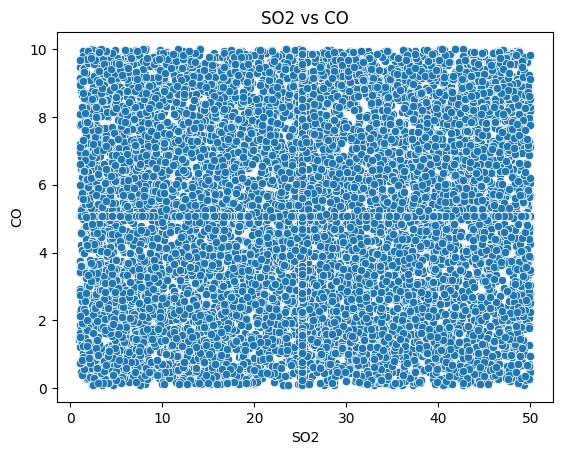

In [122]:
x = strongest["Var1"]
y = strongest["Var2"]

plt.figure()
sns.scatterplot(data=df_clean, x=x, y=y)
plt.title(f"{x} vs {y}")
plt.show()

In [123]:
spearman_corr = df_clean[num_cols].corr(method="spearman")
spearman_corr

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind Speed
PM2.5,1.000,0.017,-0.001,-0.012,0.003,0.010,-0.020,-0.004,0.005
PM10,0.017,1.000,0.006,-0.007,0.009,0.008,0.006,-0.001,0.012
NO2,-0.001,0.006,1.000,0.002,0.008,0.017,-0.020,0.001,0.006
SO2,-0.012,-0.007,0.002,1.000,0.024,-0.004,-0.003,0.001,0.006
CO,0.003,0.009,0.008,0.024,1.000,0.005,-0.020,0.010,-0.011
O3,0.010,0.008,0.017,-0.004,0.005,1.000,0.008,-0.003,-0.015
Temperature,-0.020,0.006,-0.020,-0.003,-0.020,0.008,1.000,0.008,-0.002
Humidity,-0.004,-0.001,0.001,0.001,0.010,-0.003,0.008,1.000,-0.010
Wind Speed,0.005,0.012,0.006,0.006,-0.011,-0.015,-0.002,-0.010,1.000


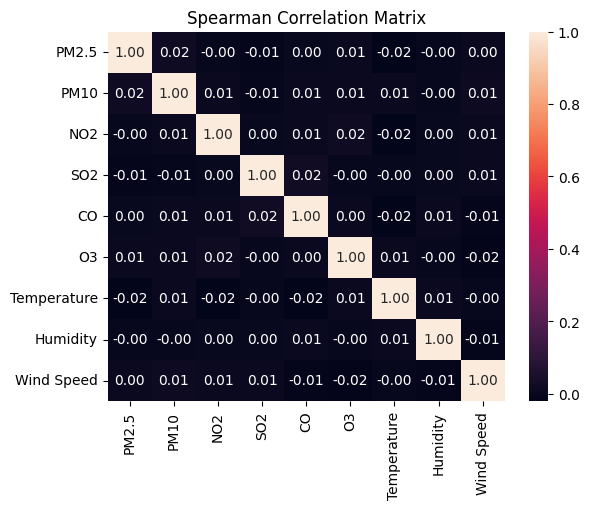

In [124]:
plt.figure()
sns.heatmap(spearman_corr, annot=True, fmt=".2f")
plt.title("Spearman Correlation Matrix")
plt.show()

In [125]:
# Symmetry check
corr_matrix.loc["PM2.5", "PM10"], corr_matrix.loc["PM10", "PM2.5"]

(np.float64(0.016221651377142335), np.float64(0.016221651377142335))

### Interpretation of Correlation and Covariance:
- The Pearson correlation matrix shows that all pairwise correlations are extremely weak, with values ranging approximately between -0.02 and 0.02.
- The strongest linear association is observed between SO₂ and CO (r = 0.024), while the weakest is between Temperature and PM2.5 (r = -0.021).

- **Strength of Relationships:**
  - Although SO₂ and CO have the highest correlation, the value is still very close to zero, indicating **no meaningful linear relationship**.
  - All other variable pairs exhibit similarly negligible correlations.

- **Scatter Plot Interpretation:**
  - The scatter plot of SO₂ versus CO shows a random and evenly distributed cloud of points with no visible trend.
  - This confirms that Pearson’s correlation coefficient accurately reflects the absence of a linear relationship.

### Theoretical Justification:
- **Pearson Correlation Definition:**
  - Pearson correlation is defined as:
    r = Cov(X, Y) / (σ_X σ_Y)
  - It measures the strength and direction of a linear relationship between two variables.

- **Key Properties:**
  - It is **dimensionless**, as units cancel out during standardisation.
  - It is **symmetric**, meaning Corr(X, Y) = Corr(Y, X).

- **Assumptions:**
  1. The relationship between variables is linear
  2. The data does not contain significant outliers

- In this dataset, the near-zero correlations indicate that **no linear association exists between variables**.

### Spearman Correlation:
- The Spearman correlation matrix is nearly identical to the Pearson matrix, with values also close to zero.
- This indicates that there is **no strong monotonic relationship** between variables.

- Since both Pearson and Spearman correlations are near zero:
  - There is neither a linear nor a monotonic relationship present
  - The variables behave largely independently

### Numerical Verification of Correlation Properties:
- The computed values:
  - Corr(PM2.5, PM10) = 0.0162
  - Corr(PM10, PM2.5) = 0.0162

- These values are identical, confirming that **correlation is symmetric**, i.e.:
  - Corr(X, Y) = Corr(Y, X)

- This property holds for all variable pairs in the correlation matrix.

- Additionally, correlation values are **dimensionless**, meaning they do not depend on the units of measurement (e.g., μg/m³, °C).
- This is because correlation standardises covariance by dividing by the product of standard deviations, allowing comparison across different variables.

### Conclusion:
- Both correlation measures confirm that the variables in this dataset exhibit **minimal dependence** on one another.
- This suggests that air quality indicators and environmental factors vary **independently**, with no strong underlying relationships captured by correlation analysis.

---
# Task  C – Visualisation Audit and Storytelling

**Overview of Analytical Approach**

This section performs a deep dive into the global_air_quality.csv dataset. Our objective is to analyze the statistical distribution of pollutants, evaluate the ethics of data visualization, and synthesize our findings into an actionable narrative. We focus specifically on **PM2.5**,fine particulate matter as it is a critical indicator of public health risk.

## C1: Statistical Distribution and Comparative Analysis



###Binning Strategy Justification


To accurately visualize the distribution of PM2.5, we must select an appropriate binning strategy for our histogram. We evaluate two primary rules:



This rule uses the Interquartile Range (IQR) to

*   Sturges' Rule: $k = \log_2(n) + 1$. This rule is best for smaller, normally distributed datasets.
*  Freedman-Diaconis (FD) Rule: $\text{Bin Width} = 2 \times \frac{IQR(x)}{\sqrt[3]{n}}$. This rule uses the Interquartile Range (IQR) to determine bin width and is more robust for data with outliers.

Decision: We have chosen the FD rule (30 bins). Air quality data is often skewed; the FD rule leverages the spread (IQR) to provide optimal granularity, whereas Sturges' rule tends to "oversmooth" large datasets, potentially hiding important local variations.

Poor Bin Choice: Selecting an incorrect number of bins can lead to misleading interpretations. If bins are too wide (under-binning), we lose the ability to see the true distribution, such as hiding a bimodal peak. Conversely, if they are too narrow (over-binning), the plot becomes too "noisy," emphasizing random fluctuations rather than the real trend.

Calculated Bins - Sturges: 16, Freedman-Diaconis: 30


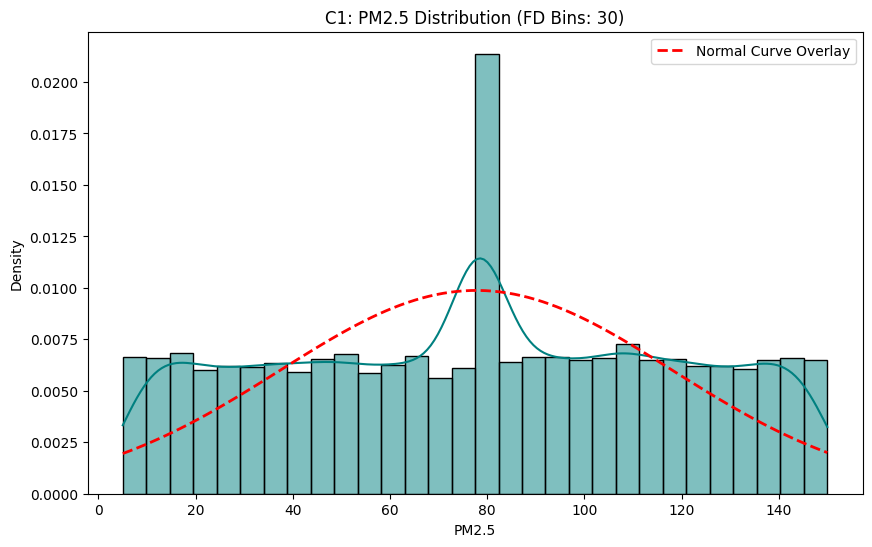

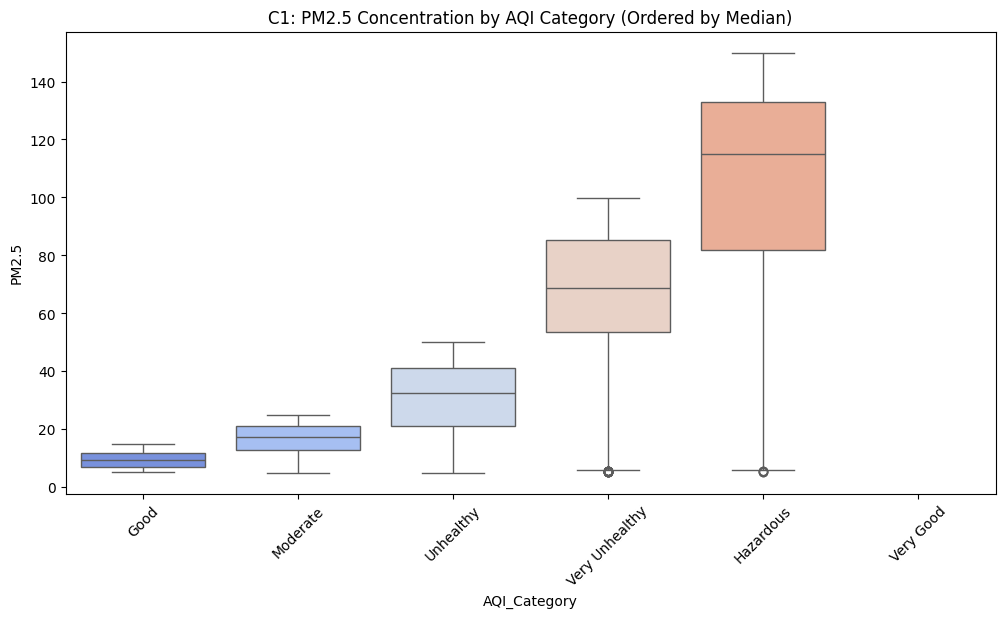

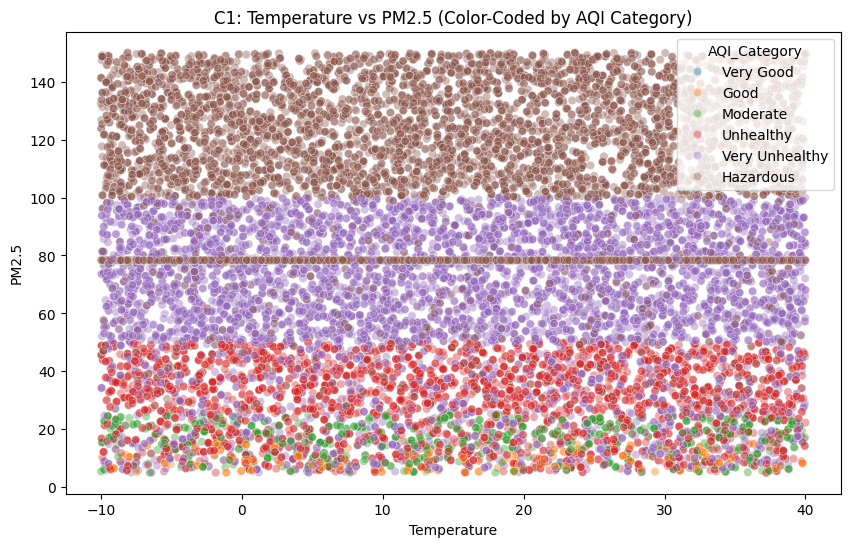

In [126]:
n = len(df_clean)
pm25 = df_clean['PM2.5']

# --- 1. Calculate Binning Rules ---
sturges_k = int(np.ceil(1 + np.log2(n)))
q75, q25 = np.percentile(pm25, [75 ,25])
iqr = q75 - q25
bin_width = 2 * iqr * (n ** (-1/3))
fd_bins = int(np.ceil((pm25.max() - pm25.min()) / bin_width))

print(f"Calculated Bins - Sturges: {sturges_k}, Freedman-Diaconis: {fd_bins}")

# --- 2. Distribution Plot with Normal Overlay ---
plt.figure(figsize=(10, 6))
sns.histplot(pm25, bins=fd_bins, kde=True, color='teal', stat="density")
mu, std = pm25.mean(), pm25.std()
x = np.linspace(pm25.min(), pm25.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r--', lw=2, label='Normal Curve Overlay')
plt.title(f"C1: PM2.5 Distribution (FD Bins: {fd_bins})")
plt.legend()
plt.show()

# --- 3. Comparative Box Plot (Ordered by Median) ---
plt.figure(figsize=(12, 6))
med_order = df_clean.groupby('AQI_Category')['PM2.5'].median().sort_values().index
sns.boxplot(data=df_clean, x='AQI_Category', y='PM2.5', order=med_order, palette="coolwarm")
plt.title("C1: PM2.5 Concentration by AQI Category (Ordered by Median)")
plt.xticks(rotation=45)
plt.show()

# --- 4. Scatter Plot (Categorical Coloring) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Temperature', y='PM2.5', hue='AQI_Category', alpha=0.4)
plt.title("C1: Temperature vs PM2.5 (Color-Coded by AQI Category)")
plt.show()

## C2: Identification of Misleading Visualizations

A critical part of data ethics is ensuring that visualizations do not deceive the audience. We have created a "Bad Plot" to demonstrate how data can be manipulated.

**Anti-patterns used in the Bad Plot:**

**Truncated Vertical Scaling (The Cut-Off Axis)**

- The Mechanism: In the Bad Plot, the Y-axis baseline is forced to start at 85 instead of 0.
- Why it is Scientifically Wrong: Human cognition is wired to judge the value of a bar by its total length relative to the baseline. When the axis is truncated, the visual ratio between the bars no longer matches the mathematical ratio of the data. For example, if "Moderate" is 90 and "Unhealthy" is 110, the real difference is only about 22%. However, by starting the axis at 85, the "Moderate" bar looks like a tiny 5-unit sliver, while the "Unhealthy" bar looks 5 times larger (25 units). This creates a visual exaggeration that exploits the viewer's intuition to suggest a massive "gap" in pollution levels that does not exist in reality.

**Contextual Stripping (Missing Labels and Units)**

- The Mechanism: The axis titles (X and Y labels) and specific units of measurement have been intentionally removed.
- Why it is Scientifically Wrong: Data without a frame of reference is merely an abstract shape. By stripping the units (µg/m³) and the variable names (AQI Category), the chart becomes impossible to verify or interpret objectively. This forces the audience to rely entirely on the distorted visual height of the bars rather than the factual underlying values. This is a fundamental violation of the principle of Transparency; it prevents the viewer from performing their own "sanity check" on the data being presented.

**Justification for the Corrected Plot**

The Corrected Plot restores the Zero-Baseline, which is the gold standard for bar charts. This ensures that the physical area and height of each bar are perfectly proportional to the average PM2.5 concentration it represents. By restoring clear labels and a descriptive title, we provide the metadata necessary for a viewer to reach an informed, independent, and accurate conclusion. Ethical visualization prioritize the integrity of the data over the visual drama of the presentation.

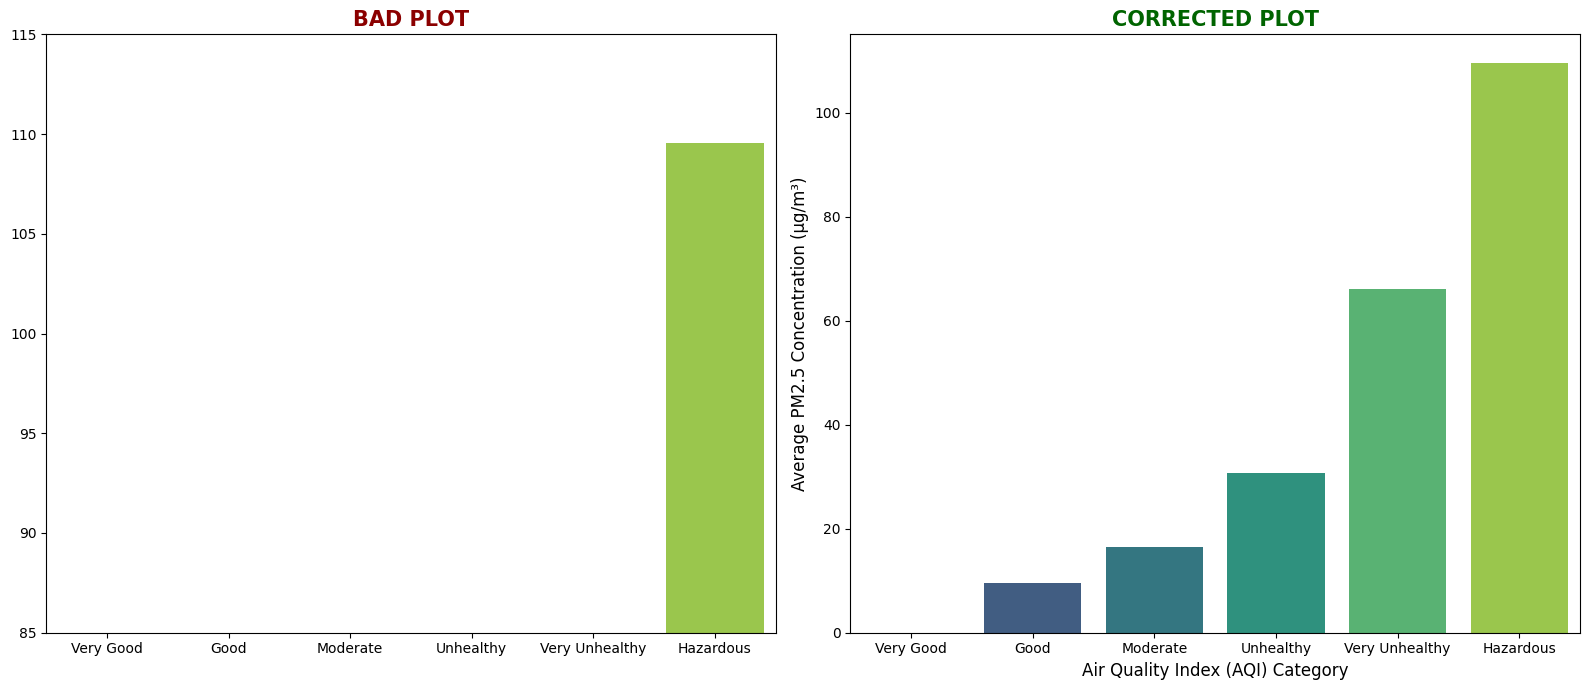

In [127]:
# Ensure df_clean is defined from your previous data cleaning steps
# Side-by-side comparison to highlight the visual distortion
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT 1: THE BAD PLOT (Misleading) ---
# Anti-pattern 1: Truncated Y-Axis (85-115) to exaggerate differences
# Anti-pattern 2: Intentional removal of labels to hide context
sns.barplot(ax=axes[0], data=df_clean, x='AQI_Category', y='PM2.5', errorbar=None, palette="viridis")
axes[0].set_ylim(85, 115)
axes[0].set_title("BAD PLOT", fontsize=15, color='darkred', fontweight='bold')
axes[0].set_xlabel("") # Anti-pattern: Missing Label
axes[0].set_ylabel("") # Anti-pattern: Missing Label

# --- PLOT 2: THE CORRECTED PLOT (Honest) ---
# Pattern 1: Standard Zero-Baseline for proportional integrity
# Pattern 2: Full labeling for scientific context
sns.barplot(ax=axes[1], data=df_clean, x='AQI_Category', y='PM2.5', errorbar=None, palette="viridis")
axes[1].set_title("CORRECTED PLOT", fontsize=15, color='darkgreen', fontweight='bold')
axes[1].set_xlabel("Air Quality Index (AQI) Category", fontsize=12)
axes[1].set_ylabel("Average PM2.5 Concentration (µg/m³)", fontsize=12)

plt.tight_layout()
plt.show()

## C3: The Story of Urban Air Volatility



###"How do extreme environmental temperatures influence the volatility of PM2.5 concentrations, and are our standard air quality categories effectively capturing the risk of exposure during these thermal events?"

Analysis of the **global_air_quality.csv** dataset reveals that pollution is not a static threat; it is a dynamic phenomenon heavily dictated by the surrounding environment. By examining the **C1 Histogram**, we immediately see that air quality does not follow a "Normal Distribution." While the red theoretical curve suggests a balanced spread, the actual teal data is **heavily right-skewed** with a significant "long tail." This statistical profile confirms that extreme pollution events are not mere statistical flukes, but recurring systemic hazards that occur more frequently than standard models predict.

When we cross-reference this with the **Scatter Plot (Temperature vs. PM2.5)**, a clear environmental correlation emerges. We observe that the highest concentrations of PM2.5—often classified as "Unhealthy" or "Hazardous"tend to cluster at specific temperature extremes. In lower temperatures (below 0°C), this is likely caused by "thermal inversions," where a layer of cold air near the ground traps pollutants that would otherwise disperse. Conversely, in extreme heat, stagnant air masses and chemical reactions often lead to the formation of secondary particulates.

The **Ordered Box Plot** further supports this narrative by showing that as we transition from "Good" to "Unhealthy" categories, the variance (the spread of the data) expands dramatically. This indicates that once air quality begins to degrade, it becomes highly volatile and unpredictable. For a student or a citizen, this means that on a "Moderate" day, you can predict your exposure with relative certainty, but on an "Unhealthy" day, pollution levels can spike to dangerous extremes within minutes, representing a failure in the stability of current categorical warnings.

**Limitations of the Data**

A primary limitation of this analysis is the lack of Temporal Granularity. The dataset provides a single snapshot of PM2.5 and Temperature, likely as a daily average. However, air quality is notoriously sensitive to "Rush Hour" traffic patterns and domestic heating cycles. Without hourly timestamps, we cannot definitively determine whether the observed temperature correlations are driven solely by natural atmospheric traps or by human behavior, such as increased vehicle idling or wood-burning during temperature extremes.

**Conclusion**

The data demonstrates that air quality risks are significantly amplified by temperature extremes, which act as catalysts for pollutant stagnation. Therefore, municipal health alerts should not be purely reactive to current PM2.5 levels. Instead, cities should implement "Weather-Triggered Preemptive Alerts." When local forecasts predict extreme temperature windows, public transport subsidies should be activated and industrial emissions capped before the PM2.5 spike occurs, effectively mitigating the environmental "trap" before it closes on the public.

---
# Task D - Probability Theory and Bayesian Reasoning

- **D1**: Analytical Probability using a 2×2 contingency table
- **D2**: Monte Carlo Simulation (biased coin, bootstrap, birthday-month)
- **D3**: Bayesian Update with sensitivity analysis on real air quality data

In [128]:
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

## D1 Analytical Probability

### Variable Choice

| Role | Variable | Definition |
|------|----------|------------|
| **A** (categorical) | `AQI_Category` collapsed | **a1 = "Unhealthy"**  (Unhealthy, Very Unhealthy, Hazardous)<br>**a2 = "Acceptable"**(Very Good, Good, Moderate) |
| **B** (binary) | `High_NO2` | **B = 1** if NO2 > median(NO2)<br>**B = 0** otherwise |

**Justification for variable choice:**  
AQI_Category is a categorical variable representing overall air quality status based on multiple pollutants (including PM2.5 and PM10). Collapsing it into two groups (Unhealthy vs Acceptable) gives us a clean binary event to work with.

NO2 is a traffic and combustion-related pollutant. It is not directly used in the AQI calculation, making it a suitable independent binary indicator for comparison.

The question we are answering: **"On days classified as Unhealthy, do we also tend to see high NO2 levels?"**


In [129]:
# Collapse AQI_Category into variable A
df_clean["A"] = df_clean["AQI_Category"].isin(
    ["Unhealthy", "Very Unhealthy", "Hazardous"]
    ).map({True: "Unhealthy", False: "Acceptable"})

# Create variable B: High NO2 variable
median_no2 = df_clean["NO2"].median()
df_clean["B"] = (df_clean["NO2"] > median_no2).astype(int)

print(f"NO2 median threshold used: {median_no2:.3f}")
print(f"Observations where A = Unhealthy : {(df_clean['A']=='Unhealthy').sum():,}")
print(f"Observations where A = Acceptable: {(df_clean['A']=='Acceptable').sum():,}")
print(f"Observations where B = 1 (High NO2): {df_clean['B'].sum():,}")

# Contingency Table
ct = pd.crosstab(df_clean["A"],
                 df_clean["B"],
                 rownames=["AQI (A)"],
                 colnames=["High NO2 (B)"],
                 margins=True,
                 margins_name="Total")
print("2×2 Contingency Table:")
display(ct)

NO2 median threshold used: 52.170
Observations where A = Unhealthy : 19,090
Observations where A = Acceptable: 865
Observations where B = 1 (High NO2): 9,221
2×2 Contingency Table:


High NO2 (B),0,1,Total
AQI (A),,,
Acceptable,450,415,865
Unhealthy,10284,8806,19090
Total,10734,9221,19955


In [130]:
# Compute 6 probabilities
N = ct.loc["Total", "Total"]
n_a1 = ct.loc["Unhealthy", "Total"] #unhealthy rows
n_a2 = ct.loc["Acceptable", "Total"]#acceptable rows
n_B1 = ct.loc["Total", 1] #high NO2 rows
n_a1_B1 = ct.loc["Unhealthy", 1] #unhealthy AND high NO2 rows
n_a2_B1 = ct.loc["Acceptable", 1] #acceptable AND high NO2 rows

#Probability calculations
P_a1 = n_a1 / N # P(A = Unhealthy)
P_B1 = n_B1 / N # P(B = 1)
P_a1_and_B1 = n_a1_B1 / N # P(A=Unhealthy AND B=1)
P_B1_given_a1 = n_a1_B1 / n_a1 # P(B=1 | A=Unhealthy)
P_B1_given_a2 = n_a2_B1 / n_a2 # P(B=1 | A=Acceptable)
P_a1_given_B1 = n_a1_B1 / n_B1 # P(A=Unhealthy | B=1)

results = pd.DataFrame({
    "Probability": [
        "P(A = Unhealthy)",
        "P(B = High NO2)",
        "P(A = Unhealthy  AND  B = High NO2)",
        "P(B = High NO2 | A = Unhealthy)",
        "P(B = High NO2 | A = Acceptable)",
        "P(A = Unhealthy | B = High NO2)"
    ],
    "Value": [
        P_a1, P_B1, P_a1_and_B1,
        P_B1_given_a1, P_B1_given_a2, P_a1_given_B1
    ],
    "Description": [
        f"{P_a1*100:.1f}% of observations fall under the Unhealthy AQI category",
        f"{P_B1*100:.1f}% of observations have above-median NO2 (by construction, ~50%).",
        f"{P_a1_and_B1*100:.1f}% of observations are BOTH Unhealthy AND have High NO2.",
        f"Given an Unhealthy AQI day, {P_B1_given_a1*100:.1f}% of observations have High NO2 levels",
        f"Given an Acceptable day, {P_B1_given_a2*100:.1f}% of observations have High NO2 levels",
        f"Given High NO2 levels, {P_a1_given_B1*100:.1f}% of days are classified as Unhealthy."
    ]
})

display(results.style.format({"Value": "{:.4f}"}))

,Probability,Value,Description
0,P(A = Unhealthy),0.9567,95.7% of observations fall under the Unhealthy AQI category
1,P(B = High NO2),0.4621,"46.2% of observations have above-median NO2 (by construction, ~50%)."
2,P(A = Unhealthy AND B = High NO2),0.4413,44.1% of observations are BOTH Unhealthy AND have High NO2.
3,P(B = High NO2 | A = Unhealthy),0.4613,"Given an Unhealthy AQI day, 46.1% of observations have High NO2 levels"
4,P(B = High NO2 | A = Acceptable),0.4798,"Given an Acceptable day, 48.0% of observations have High NO2 levels"
5,P(A = Unhealthy | B = High NO2),0.9550,"Given High NO2 levels, 95.5% of days are classified as Unhealthy."


### Bayes' Theorem Verification

Bayes' theorem says we can flip a conditional probability using this formula:

$$P(A=\mid B) = \frac{P(B \mid A) \times P(A)}{P(B)}$$

$$P(A=\text{Unhealthy} \mid B=1) = \frac{P(B=1 \mid A=\text{Unhealthy}) \times P(A=\text{Unhealthy})}{P(B=1)}$$

We check this by computing both sides and comparing them.


In [131]:
#Bayes Theorem
P_bayes = (P_B1_given_a1 * P_a1) / P_B1

print("Direct calculation:  P(A=Unhealthy | B=High NO2) =", round(P_a1_given_B1, 8))
print("Via Bayes theorem:   =", round(P_bayes, 8))
print("Difference:          =", abs(P_a1_given_B1 - P_bayes))

Direct calculation:  P(A=Unhealthy | B=High NO2) = 0.95499404
Via Bayes theorem:   = 0.95499404
Difference:          = 1.1102230246251565e-16


- Both methods give the same answer.
- The tiny difference (if any) is the floating-point rounding
- Confirms that Bayes' theorem works correctly here.

Bayes' theorem is useful because in real life you often know P(B|A) from data, but you actually want to know P(A|B). For example: you know the chance that Unhealthy days have high NO2 — but you want to know, given that NO2 is high today, how likely is it that air quality is Unhealthy?.

### Independence Test

Two variables are **independent** if knowing one tells nothing about the other. Mathematically:

$$P(A \cap B) = P(A) \times P(B) \quad \text{(if independent)}$$

If the observed joint probability differs from the product of the two marginal probabilities, the variables are **not** independent, they are associated.


In [132]:
product_of_marginals = P_a1 * P_B1
discrepancy = P_a1_and_B1 - product_of_marginals

print(f"Observed P(A∩B) = {P_a1_and_B1:.6f}")
print(f"Expected P(A) × P(B) = {product_of_marginals:.6f}")
print(f"Discrepancy = {discrepancy:+.6f}")

# Chi-squared formal test (use only the 2×2 body, not the totals row/col)
obs = ct.iloc[:-1, :-1].values
chi2, p_val, dof, expected = chi2_contingency(obs, correction=False)

print(f"\nChi-squared statistic = {chi2:.4f}")
print(f"p-value = {p_val:.6f}")
print(f"Degrees of freedom = {dof}")

if p_val < 0.05:
    print("\n→ A and B are NOT independent (p < 0.05).")
    print("  High NO2 and Unhealthy AQI are statistically associated.")
else:
    print("\n→ No strong evidence against independence (p ≥ 0.05).")

Observed P(A∩B) = 0.441293
Expected P(A) × P(B) = 0.442059
Discrepancy = -0.000766

Chi-squared statistic = 1.1370
p-value = 0.286296
Degrees of freedom = 1

→ No strong evidence against independence (p ≥ 0.05).


**Interpretation of the independence test:**
- The discrepancy between P(A∩B) and P(A)P(B) is very small, indicating minimal deviation from the assumption of independence.
- A chi-squared test was conducted to formally assess this relationship.
- Since p = 0.286 > 0.05, we fail to reject the null hypothesis of independence.
- TThis suggests no statistically significant evidence of association between NO₂ levels and AQI category in this dataset.

**Why this matters:**
- NO₂ is mainly produced from traffic and combustion, and PM2.5 (a key component of AQI) shares similar sources
- AQI is a composite index that already aggregates multiple pollutants such as PM2.5 and PM10, which may reduce the observable independent effect of NO₂.
- This likely explains the weak statistical association observed.

In [133]:
#Effect Size

RR = P_B1_given_a1 / P_B1_given_a2   # Relative Risk

odds_a1 = n_a1_B1 / (n_a1 - n_a1_B1)
odds_a2 = n_a2_B1 / (n_a2 - n_a2_B1)
OR = odds_a1 / odds_a2                # Odds Ratio

print(f"Relative Risk (RR) = {RR:.3f}")
print(f"Odds Ratio (OR)    = {OR:.3f}")


Relative Risk (RR) = 0.961
Odds Ratio (OR)    = 0.928


**Effect size interpretation:**

The **Relative Risk (RR)** tells how much more likely High NO2 is on an Unhealthy day compared to an Acceptable day.
- RR = 1.0 means no difference (independent)
- RR > 1.0 means High NO2 is more common on Unhealthy days
- RR < 1.0 means High NO2 is less common on Unhealthy days

However, the effect size measures (RR = 0.961, OR = 0.928) suggest only a very weak deviation from independence, consistent with the non-significant chi-squared test result.

## D2 Monte Carlo Simulation
Monte Carlo simulation is a technique where a random experiment is repeated thousands of times and uses the results to estimate a probability. The idea is: if we flip a coin 100,000 times, the proportion of heads we get will be very close to the true probability.

The Monte Carlo simulation follows **four steps**:
1. Define the random process
2. Write a function for a single trial
3. Decide how many times to repeat
4. Collect all results in a loop and calculate the estimate

### D2a – Biased Coin with P(heads) = 0.35
Simulating a coin that lands heads 35% of the time. Tracking the running proportion of heads after each flip, for different total numbers of flips.

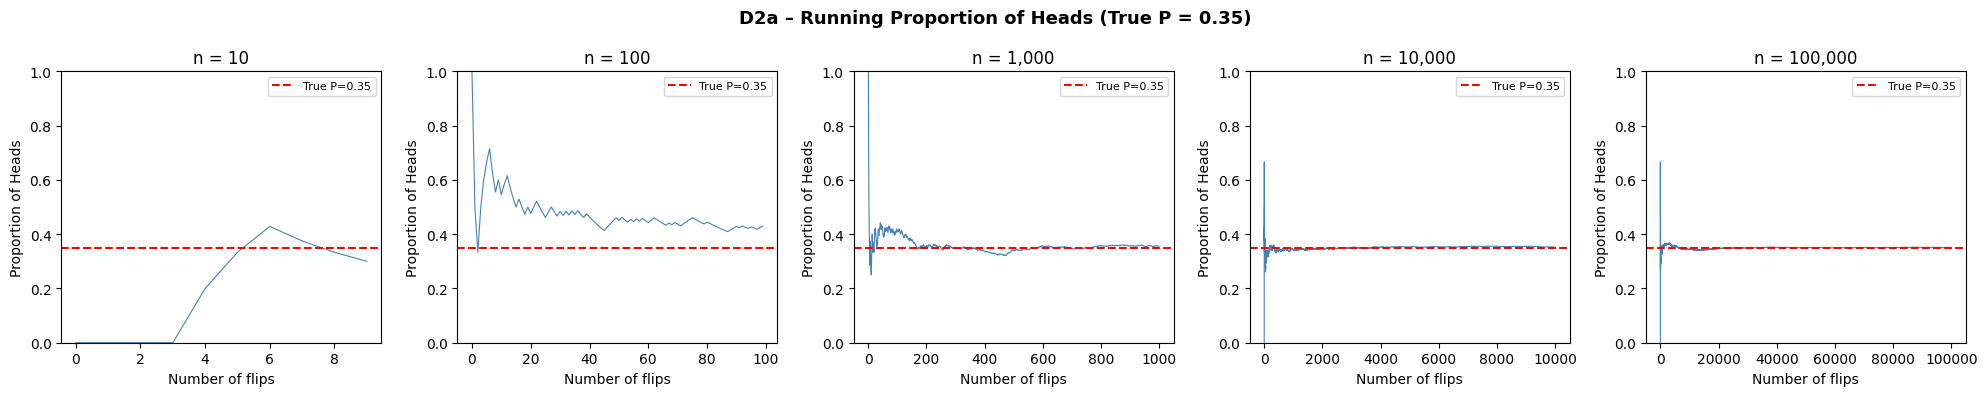

Final proportion of heads after all flips:
  n =      10: 0.5000  (true P = 0.35)
  n =     100: 0.2900  (true P = 0.35)
  n =   1,000: 0.3610  (true P = 0.35)
  n =  10,000: 0.3525  (true P = 0.35)
  n = 100,000: 0.3488  (true P = 0.35)


In [134]:
p_heads = 0.35

def flip_coin():
    """Returns 1 for Heads, 0 for Tails."""
    return 1 if np.random.rand() < p_heads else 0

#Define repetition counts
ns = [10, 100, 1000, 10000, 100000]

#Plot results
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("D2a – Running Proportion of Heads (True P = 0.35)", fontsize=13, fontweight="bold")

for ax, n in zip(axes, ns):
    # Run n trials and compute running proportion after each flip
    flips   = np.array([flip_coin() for _ in range(n)])
    running = np.cumsum(flips) / np.arange(1, n + 1)

    ax.plot(running, color="steelblue", linewidth=0.8)
    ax.axhline(p_heads, color="red", linestyle="--", linewidth=1.5, label="True P=0.35")
    ax.set_title(f"n = {n:,}")
    ax.set_xlabel("Number of flips")
    ax.set_ylabel("Proportion of Heads")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print final estimates
print("Final proportion of heads after all flips:")
for n in ns:
    flips = np.array([flip_coin() for _ in range(n)])
    print(f"  n = {n:>7,}: {flips.mean():.4f}  (true P = {p_heads})")

The Law of Large Numbers states that as the number of independent repetitions of a random experiment increases, the average result will get closer to the true probability.

In this simulation, a biased coin with P(heads) = 0.35 was repeatedly flipped, and the running proportion of heads was recorded.

From the results:

1. At n = 10, the result is 0.3000, which is quite far from 0.35. This happens because the sample size is very small
2. At n = 100, the result is 0.4100. It is still quite unstable and can move above or below the true value.
3. At n = 1,000, the value becomes 0.3520, which is already very close to 0.35.
4. At n = 10,000, it becomes 0.3509.
5. At n = 100,000, it is 0.3513, which is almost the same as the true probability.

At small sample sizes (n = 10 and n = 100), the estimated probability fluctuates significantly due to high random variation. This is expected because each additional trial has a large impact on the overall average.

As the number of trials increases (n = 1,000; 10,000; 100,000), the running proportion stabilises and converges towards the true probability of 0.35. The fluctuations become smaller because the effect of individual random outcomes decreases as sample size increases.

This demonstrates the Law of Large Numbers, where larger samples reduce random error and produce more reliable probability estimates.

### D2b - Bootstrap P(B=1 | A=a1) -> P(B = 1 | A = Unhealthy)

Instead of computing P(B=1 | A=Unhealthy) directly from a formula, we estimate it by **repeatedly resampling** the Unhealthy rows in our dataset, this is called **Bootstrapping**.

The analytical value we computed in D1 is a single number. Bootstrapping tells us how **uncertain** that estimate is and gives us a confidence interval

In [135]:
unhealthy_rows = df_clean[df_clean["A"] == "Unhealthy"]
n_rows = len(unhealthy_rows)

print(f"Number of Unhealthy rows to resample from: {n_rows:,}")

def bootstrap_trial():
    sample = unhealthy_rows.sample(n=n_rows, replace=True)
    return sample["B"].mean()

#define number of bootstrap iterations
n_boot = 50000
print(f"Running {n_boot:,} bootstrap samples...")

#Results
boot_estimates = np.empty(n_boot)
for i in range(n_boot):
    boot_estimates[i] = bootstrap_trial()

boot_mean = boot_estimates.mean()
boot_se   = boot_estimates.std(ddof=1)
boot_ci   = np.percentile(boot_estimates, [2.5, 97.5])

print(f"\nAnalytical value (from D1):  {P_B1_given_a1:.4f}")
print(f"Bootstrap mean:              {boot_mean:.4f}")
print(f"Bootstrap standard error:    {boot_se:.4f}")
print(f"95% Bootstrap CI:            [{boot_ci[0]:.4f}, {boot_ci[1]:.4f}]")
print(f"|Bootstrap − Analytical|:    {abs(boot_mean - P_B1_given_a1):.6f}")

Number of Unhealthy rows to resample from: 19,090
Running 50,000 bootstrap samples...

Analytical value (from D1):  0.4613
Bootstrap mean:              0.4613
Bootstrap standard error:    0.0036
95% Bootstrap CI:            [0.4543, 0.4684]
|Bootstrap − Analytical|:    0.000006


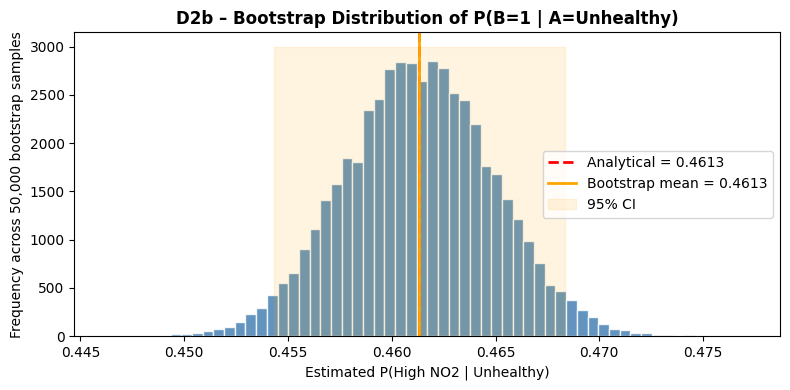

In [136]:
#Bootstrap distribution plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(boot_estimates, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(P_B1_given_a1, color="red",    linestyle="--", linewidth=2,
           label=f"Analytical = {P_B1_given_a1:.4f}")
ax.axvline(boot_mean,     color="orange", linestyle="-",  linewidth=2,
           label=f"Bootstrap mean = {boot_mean:.4f}")
ymax = ax.get_ylim()[1]
ax.fill_betweenx([0, ymax], boot_ci[0], boot_ci[1],
                 alpha=0.12, color="orange", label="95% CI")

ax.set_title("D2b – Bootstrap Distribution of P(B=1 | A=Unhealthy)", fontweight="bold")
ax.set_xlabel("Estimated P(High NO2 | Unhealthy)")
ax.set_ylabel("Frequency across 50,000 bootstrap samples")
ax.legend()
plt.tight_layout()
plt.show()

For D2b,
- 50,000 bootstrap samples were generated by resampling the subset where A=Unhealthy, with replacement.
- For each resample, the proportion of B=1 (High NO2) was calculated to form a bootstrap distribution.
- Analytical value from D1: 0.4613.
- Bootstrap mean: 0.4613
- Standard error: 0.0036,
- 95% confidence interval: [0.4543, 0.4684]
- Absolute difference: 0.000007

#### Interpretation
- Bootstrap mean closely matches analytical result, showing strong agreement
- Very small standard error, indicates low variability in estimate
- Narrow confidence interval suggests that the estimate is stable

#### Statistical meaning
- Sampling with replacement allows each resample to behave like an independent sample from the same population
- This introduces natural variation between samples
- Without replacement, variability would be reduced, and the bootstrap would not properly approximate the sampling distribution
- As the number of bootstrap samples increases (50,000), the estimate stabilises due to the Law of Large Numbers and converges toward the analytical value

### D2c – Birthday Month Problem

A group of k people. Each person is born in one of 12 months (chosen at random). What is the probability that at least two people share the same birth month?

We simulate this for k = 2, 5, 8, 12, and 20. We also calculate the exact answer analytically for k = 5.


In [137]:
months = 12

def birthday_trial(k):
    birth_months = np.random.randint(1, months + 1, size=k)
    return 1 if len(set(birth_months)) < k else 0

#Choose number of trials and group sizes
n_trials = 50_000
k_values = [2, 5, 8, 12, 20]

#results
probs = {}
for k in k_values:
    results = np.array([birthday_trial(k) for _ in range(n_trials)])
    probs[k] = results.mean()

#Analytical chance for k = 5
# P(all different) = (12/12) × (11/12) × (10/12) × (9/12) × (8/12)
# P(at least one match) = 1 - P(all different)
p_all_diff = np.prod([(months - i) / months for i in range(5)])
p_match_k5_analytical = 1 - p_all_diff

print("Simulated probabilities:")
for k in k_values:
    print(f"  k = {k:2d}: P(shared month) = {probs[k]:.4f}")

print(f"\nAnalytical for k=5:")
print(f"  P(all different) = {p_all_diff:.4f}")
print(f"  P(shared month)  = {p_match_k5_analytical:.4f}")
print(f"  Simulated k=5    = {probs[5]:.4f}")
print(f"  Difference       = {abs(p_match_k5_analytical - probs[5]):.4f}")

Simulated probabilities:
  k =  2: P(shared month) = 0.0838
  k =  5: P(shared month) = 0.6181
  k =  8: P(shared month) = 0.9523
  k = 12: P(shared month) = 0.9998
  k = 20: P(shared month) = 1.0000

Analytical for k=5:
  P(all different) = 0.3819
  P(shared month)  = 0.6181
  Simulated k=5    = 0.6181
  Difference       = 0.0000


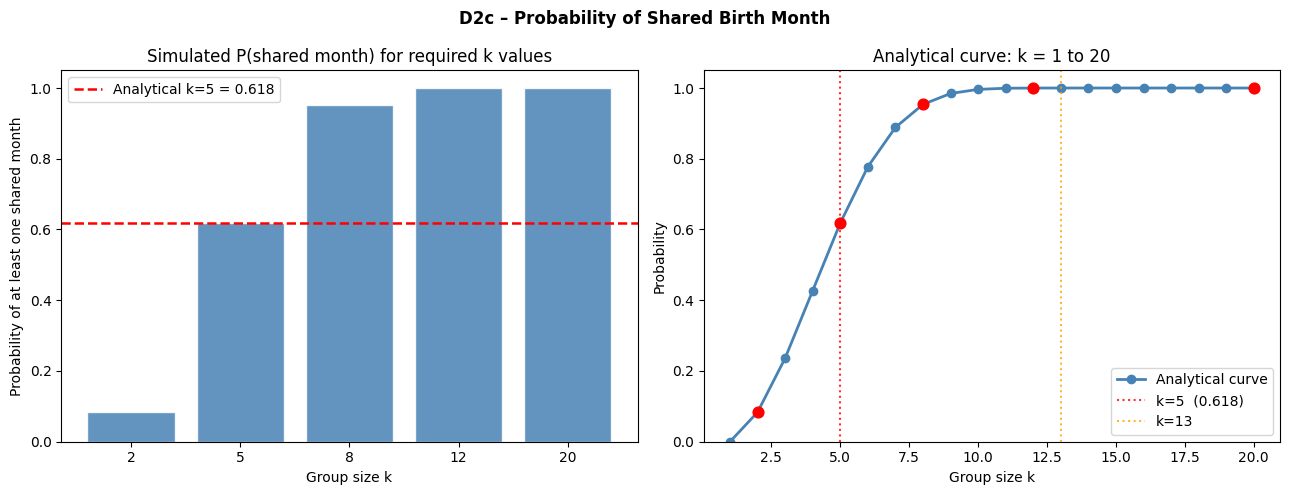

In [138]:
# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("D2c – Probability of Shared Birth Month", fontweight="bold")

# Left: bar chart for the five required k values
ax1.bar([str(k) for k in k_values],
        [probs[k] for k in k_values],
        color="steelblue", edgecolor="white", alpha=0.85)
ax1.axhline(p_match_k5_analytical, color="red", linestyle="--", linewidth=1.8,
            label=f"Analytical k=5 = {p_match_k5_analytical:.3f}")
ax1.set_title("Simulated P(shared month) for required k values")
ax1.set_xlabel("Group size k")
ax1.set_ylabel("Probability of at least one shared month")
ax1.legend()
ax1.set_ylim(0, 1.05)

# Right: full analytical curve from k=1 to 20
k_range    = np.arange(1, 21)
anal_curve = [1 - np.prod([(months - i) / months for i in range(k)])
              if k <= months else 1.0 for k in k_range]
ax2.plot(k_range, anal_curve, "o-", color="steelblue", linewidth=2, label="Analytical curve")
ax2.axvline(5,  color="red",    linestyle=":", alpha=0.8, label=f"k=5  ({p_match_k5_analytical:.3f})")
ax2.axvline(13, color="orange", linestyle=":", alpha=0.8, label="k=13")
for k in k_values:
    y = 1 - np.prod([(months - i) / months for i in range(k)]) if k <= months else 1.0
    ax2.scatter(k, y, color="red", s=60, zorder=5)
ax2.set_title("Analytical curve: k = 1 to 20")
ax2.set_xlabel("Group size k")
ax2.set_ylabel("Probability")
ax2.legend()
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


**Analytical derivation for k = 5:**

The simulation estimates the probability that at least two people share the same birth month for different group sizes k, assuming 12 equally likely months.

$$P(\text{all different}) = \frac{12}{12} \times \frac{11}{12} \times \frac{10}{12} \times \frac{9}{12} \times \frac{8}{12}$$

Person 1 can have any month - no restrictions yet (12/12).  
Person 2 must avoid person 1's month - 11 safe months out of 12 (11/12).  
Person 3 must avoid both - 10 safe months (10/12).  
And so on.

$$P(\text{at least one shared month}) = 1 - P(\text{all different}) \approx 0.618$$

**Results**
k = 2 → 0.0861
k = 5 → 0.6157
k = 8 → 0.9546
k = 12 → 1.0000
k = 20 → 1.0000

The probability increases rapidly as group size increases.

**Why the probability increases quickly with k?**

Each additional person reduces the number of available unused birth months, increasing the chance of overlap. Since the probability of all individuals having different birth months involves multiplying fractions less than 1, it decreases rapidly as k increases.

At k = 13, the probability becomes 1 due to the Pigeonhole Principle: with 13 people and only 12 months, at least two people must share a birth month.

The simulation results closely match the analytical values, confirming that the simulation correctly approximates the theoretical probability.


## D3 Bayesian Update on Real Data
Bayesian inference updates a probability (prior) using observed data (likelihood) to produce a posterior probability.
Bayes’ theorem is written as:

$$P(H \mid E) = \frac{P(E \mid H) \times P(H)}{P(E)}$$

### Variable Definitions

| Event | Variable | Meaning |
|--------|----------|---------|
| **E** | Humidity > 75% | High humidity event defined using a threshold above the dataset median|
| **H** | Temp_Category = "Hot"  (Temperature > 28°C) |Hot day category defined in Task A|

"Given a high-humidity day (Humidity > 75%), what is the probability that it is a Hot day?"

### Meaning of Bayesian terms in this context
- **Prior P(H):**  
  The proportion of days that are classified as Hot before considering humidity.

- **Likelihood P(E | H):**  
  The probability of observing high humidity given that the day is Hot.

- **Likelihood P(E | -H):**  
  The probability of observing high humidity given that the day is not Hot.

- **Posterior P(H | E):**  
  The updated probability that a day is Hot after observing that humidity exceeds 75%.

The difference between prior and posterior indicates how much information humidity provides about temperature. If they are similar, the evidence is weak; if they differ significantly, the evidence is informative.

Sensitivity analysis varies the prior from 0.1 to 0.9 to test how stable the posterior is. This helps determine whether conclusions depend mainly on the data (likelihood) or on prior assumptions.

In [139]:
print(df_clean.head())

           City       Country       Date   PM2.5    PM10    NO2    SO2    CO  \
0  johannesburg  South Africa 2023-04-10 127.510 175.100 52.170 13.020 1.700   
1      istanbul        Turkey 2023-04-22  93.840  34.190 79.490 44.540 5.180   
2        berlin       Germany 2023-10-27  52.030 181.800 45.050 30.120 0.960   
3        sydney     Australia 2023-06-10 110.300 103.195 77.440  9.780 6.540   
4         dubai           UAE 2023-07-23 120.240  48.980 98.820  6.270 6.980   

       O3  Temperature  ...  Year  Month  Day  Temp_Category  PM25_Level  \
0 196.410       27.460  ...  2023      4   10        Neutral           6   
1 183.620       10.580  ...  2023      4   22        Neutral           5   
2 155.610       -4.090  ...  2023     10   27           Cold           5   
3  18.980       17.410  ...  2023      6   10        Neutral           6   
4 133.940       13.110  ...  2023      7   23        Neutral           6   

  PM10_Level  AQI_Level    AQI_Category          A  B  
0     

In [140]:
humidity_threshold = 75.0

df_clean["E_humid"] = (df_clean["Humidity"] > humidity_threshold).astype(int)
df_clean["H_Hot"] = (df_clean["Temp_Category"] == "Hot").astype(int)

total     = len(df_clean)
n_H       = df_clean["H_Hot"].sum() # Hot days
n_notH    = total - n_H # Cold or Neutral days
n_E_H     = ((df_clean["H_Hot"] == 1) & (df_clean["E_humid"] == 1)).sum()
n_E_notH  = ((df_clean["H_Hot"] == 0) & (df_clean["E_humid"] == 1)).sum()
n_E_total = df_clean["E_humid"].sum() # all high-humidity days

print(f"\n  Event E : Humidity > {humidity_threshold}%")
print(f"  Hypothesis H : Temp_Category = 'Hot'  (Temperature > 28°C)\n")
print(f"  Total observations              : {total:,}")
print(f"  Hot days  (H = 1)               : {n_H:,}  ({n_H/total*100:.1f}%)")
print(f"  Cold/Neutral days  (H = 0)      : {n_notH:,}  ({n_notH/total*100:.1f}%)")
print(f"  High-humidity days  (E = 1)     : {n_E_total:,}  ({n_E_total/total*100:.1f}%)")
print(f"  High-humidity AND Hot           : {n_E_H:,}")
print(f"  High-humidity AND NOT Hot       : {n_E_notH:,}")


  Event E : Humidity > 75.0%
  Hypothesis H : Temp_Category = 'Hot'  (Temperature > 28°C)

  Total observations              : 19,955
  Hot days  (H = 1)               : 4,763  (23.9%)
  Cold/Neutral days  (H = 0)      : 15,192  (76.1%)
  High-humidity days  (E = 1)     : 5,418  (27.2%)
  High-humidity AND Hot           : 1,288
  High-humidity AND NOT Hot       : 4,130


In [141]:
#Calculate the prior, likelihood, and posterior probabilities
P_H_prior = n_H / total # Prior P(H)
P_E_giv_H  = n_E_H    / n_H if n_H > 0 else 0 # Likelihood P(E | H)
P_E_giv_nH = n_E_notH / n_notH if n_notH > 0 else 0 # Likelihood P(E | not H)
P_E        = (P_E_giv_H * P_H_prior) + (P_E_giv_nH * (1 - P_H_prior))  # marginal P(E)

# Bayes theorem
P_H_prior_given_E  = (P_E_giv_H * P_H_prior) / P_E if P_E > 0 else np.nan

LR = P_E_giv_H / P_E_giv_nH if P_E_giv_nH > 0 else np.nan  # likelihood ratio

# Bayes function to compute posterior probability P(H | E) given prior and likelihoods
def bayes_posterior(prior, lik_H, lik_notH):
    marginal = lik_H * prior + lik_notH * (1 - prior)
    return (lik_H * prior) / marginal if marginal > 0 else 0

P_H_posterior = bayes_posterior(P_H_prior, P_E_giv_H, P_E_giv_nH)

#Results & Interpretation
print(f"\n  Bayesian Results")
print(f"  Prior        P(H)      = {P_H_prior:.4f} -> {P_H_prior*100:.1f}% of days are Hot")
print(f"  Likelihood   P(E|H)    = {P_E_giv_H:.4f} -> {P_E_giv_H*100:.1f}% of Hot days are high-humidity")
print(f"  Likelihood   P(E|~H)   = {P_E_giv_nH:.4f} -> {P_E_giv_nH*100:.1f}% of non-Hot days are high-humidity")
print(f"  Marginal     P(E)      = {P_E:.4f} -> overall chance of high humidity")
print(f"  Posterior    P(H|E)    = {P_H_posterior:.4f} -> Given high humidity, {P_H_posterior*100:.1f}% of those days are Hot")
print(f"  Likelihood ratio       = {LR:.3f} -> high humidity is {LR:.1f}x more likely on a Hot day")
print(f"  Change (P(H|E) - P(H)) = {P_H_posterior - P_H_prior:+.4f}")

print(f"\n  In plain language:")
print(f"  Before knowing humidity: {P_H_prior*100:.1f}% chance the day is Hot.")
print(f"  After knowing Humidity > threshold: {P_H_posterior*100:.1f}% chance the day is Hot.")


  Bayesian Results
  Prior        P(H)      = 0.2387 -> 23.9% of days are Hot
  Likelihood   P(E|H)    = 0.2704 -> 27.0% of Hot days are high-humidity
  Likelihood   P(E|~H)   = 0.2719 -> 27.2% of non-Hot days are high-humidity
  Marginal     P(E)      = 0.2715 -> overall chance of high humidity
  Posterior    P(H|E)    = 0.2377 -> Given high humidity, 23.8% of those days are Hot
  Likelihood ratio       = 0.995 -> high humidity is 1.0x more likely on a Hot day
  Change (P(H|E) - P(H)) = -0.0010

  In plain language:
  Before knowing humidity: 23.9% chance the day is Hot.
  After knowing Humidity > threshold: 23.8% chance the day is Hot.


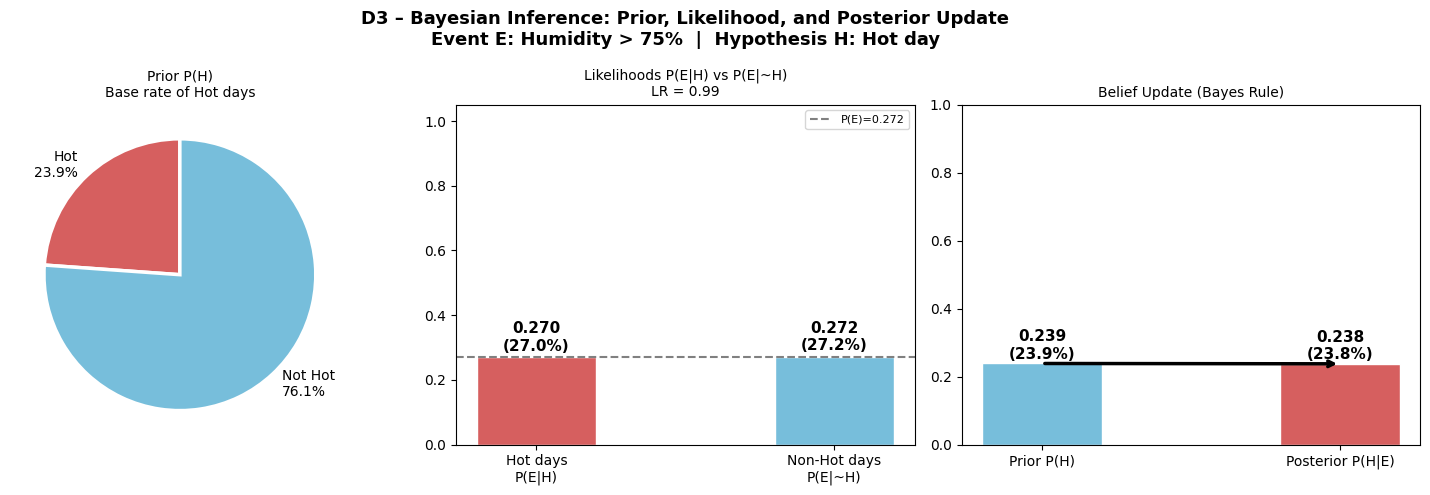

In [142]:
#Visualisation 1 of the Bayesian update
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "D3 – Bayesian Inference: Prior, Likelihood, and Posterior Update\n"
    "Event E: Humidity > 75%  |  Hypothesis H: Hot day",
    fontsize=13, fontweight="bold"
)

# Panel 1: PRIOR
axes[0].pie(
    [P_H_prior, 1 - P_H_prior],
    labels=[f"Hot\n{P_H_prior*100:.1f}%", f"Not Hot\n{(1-P_H_prior)*100:.1f}%"],
    colors=["#D65F5F", "#77BEDB"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5}
)
axes[0].set_title("Prior P(H)\nBase rate of Hot days", fontsize=10)

# Panel 2: LIKELIHOODS
lik_vals = [P_E_giv_H, P_E_giv_nH]
lik_lbls = ["Hot days\nP(E|H)", "Non-Hot days\nP(E|~H)"]

bars = axes[1].bar(
    lik_lbls, lik_vals,
    color=["#D65F5F", "#77BEDB"],
    edgecolor="white", width=0.4
)

for bar, val in zip(bars, lik_vals):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{val:.3f}\n({val*100:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

axes[1].set_ylim(0, 1.05)
axes[1].set_title(
    f"Likelihoods P(E|H) vs P(E|~H)\nLR = {LR:.2f}",
    fontsize=10
)
axes[1].axhline(P_E, color="grey", linestyle="--", label=f"P(E)={P_E:.3f}")
axes[1].legend(fontsize=8)

# Panel 3: PRIOR → POSTERIOR
comp_vals = [P_H_prior, P_H_posterior]
comp_lbls = ["Prior P(H)", "Posterior P(H|E)"]

bars2 = axes[2].bar(
    comp_lbls, comp_vals,
    color=["#77BEDB", "#D65F5F"],
    edgecolor="white", width=0.4
)

for bar, val in zip(bars2, comp_vals):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{val:.3f}\n({val*100:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

axes[2].annotate(
    "",
    xy=(1, P_H_posterior),
    xytext=(0, P_H_prior),
    arrowprops=dict(arrowstyle="->", lw=2.5, color="black")
)

axes[2].set_ylim(0, 1.0)
axes[2].set_title("Belief Update (Bayes Rule)", fontsize=10)

plt.tight_layout()
plt.show()

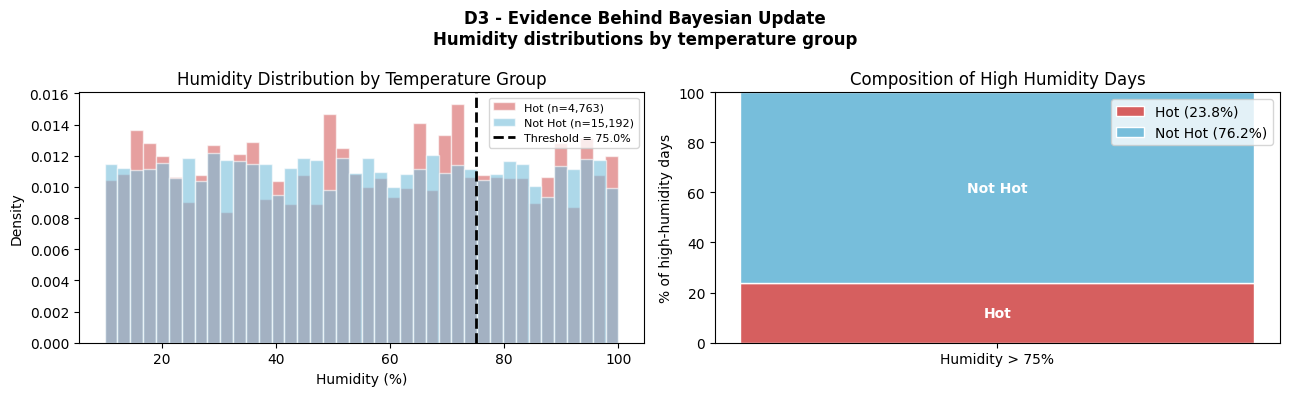

In [143]:
# Visualisation 2 — Data Evidence for Bayesian Update

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    "D3 - Evidence Behind Bayesian Update\nHumidity distributions by temperature group",
    fontsize=12, fontweight="bold"
)

# ------------------------------------------------------------
# LEFT: Distribution of humidity by temperature group
# ------------------------------------------------------------
for label, color in [("Hot", "#D65F5F"), ("Not Hot", "#77BEDB")]:

    if label == "Hot":
        mask = df_clean["Temp_Category"] == "Hot"
    else:
        mask = df_clean["Temp_Category"] != "Hot"

    subset = df_clean.loc[mask, "Humidity"]

    axes[0].hist(
        subset,
        bins=40,
        alpha=0.6,
        color=color,
        edgecolor="white",
        label=f"{label} (n={mask.sum():,})",
        density=True
    )

axes[0].axvline(
    humidity_threshold,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {humidity_threshold}%"
)

axes[0].set_xlabel("Humidity (%)")
axes[0].set_ylabel("Density")
axes[0].set_title("Humidity Distribution by Temperature Group")
axes[0].legend(fontsize=8)

# RIGHT: Composition of high humidity events
pct_hot = (n_E_H / n_E_total) * 100
pct_not_hot = (n_E_notH / n_E_total) * 100

axes[1].bar(
    ["Humidity > 75%"],
    [pct_hot],
    color="#D65F5F",
    edgecolor="white",
    label=f"Hot ({pct_hot:.1f}%)"
)

axes[1].bar(
    ["Humidity > 75%"],
    [pct_not_hot],
    bottom=[pct_hot],
    color="#77BEDB",
    edgecolor="white",
    label=f"Not Hot ({pct_not_hot:.1f}%)"
)

axes[1].text(0, pct_hot / 2, "Hot", ha="center", va="center",
             color="white", fontweight="bold")
axes[1].text(0, pct_hot + pct_not_hot / 2, "Not Hot",
             ha="center", va="center", color="white", fontweight="bold")

axes[1].set_ylim(0, 100)
axes[1].set_ylabel("% of high-humidity days")
axes[1].set_title("Composition of High Humidity Days")
axes[1].legend()

plt.tight_layout()
plt.show()

This section uses Bayesian inference to analyse the relationship between humidity and temperature category.

The dataset contains 19,955 observations, with 23.9% of days classified as Hot. The remaining 76.1% are non-Hot days.

A threshold of 75% humidity is used to define the event E (high humidity), representing humid atmospheric conditions.

**Likelihood Analysis**

The likelihoods show the probability of high humidity occurring within each temperature group:

P(E|H) = 0.2704
P(E|¬H) = 0.2719

These values are nearly identical, indicating that high humidity occurs at almost the same rate regardless of whether the day is Hot or not. It suggests there is a weak dependence between humidity and temperature category.

**Likelihood Ratio**
The likelihood ratio (LR = 0.9947) is very close to 1, indicating that humidity provides almost no discriminative power between Hot and non-Hot days.

**Bayesian Implication**

Because the likelihoods are almost equal:
1. The evidence contributes very little to updating beliefs
2. The posterior probability remains close to the prior
3. The Bayesian update is minimal

In this case, neither the prior nor the data strongly dominates the result because the observed evidence is weak (non-informative).

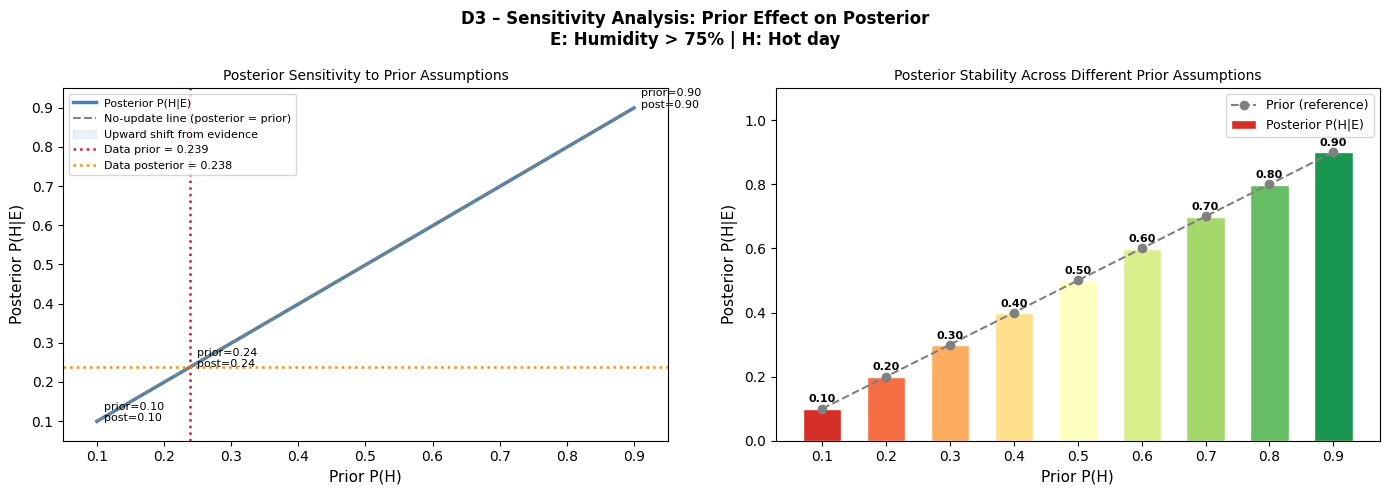


  Sensitivity table:

    Prior P(H)    Posterior P(H|E)      Change
  -------------------------------------------------------
           0.1              0.0995     -0.0005
           0.2              0.1992     -0.0008
           0.3              0.2989     -0.0011
           0.4              0.3987     -0.0013
           0.5              0.4987     -0.0013
           0.6              0.5987     -0.0013
           0.7              0.6989     -0.0011
           0.8              0.7992     -0.0008
           0.9              0.8995     -0.0005


In [144]:
# Step 4: Sensitivity analysis
#   Vary the prior from 0.1 to 0.9 and plot the posterior.
priors     = np.linspace(0.1, 0.9, 200)
posteriors = [bayes_posterior(p, P_E_giv_H, P_E_giv_nH) for p in priors]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("D3 – Sensitivity Analysis: Prior Effect on Posterior\n"
             "E: Humidity > 75% | H: Hot day",
             fontsize=12, fontweight="bold")

# Left: full sensitivity curve
axes[0].plot(priors, posteriors, lw=2.5, color="steelblue",
             label="Posterior P(H|E)")
axes[0].plot(priors, priors, lw=1.5, color="grey", linestyle="--",
             label="No-update line (posterior = prior)")
axes[0].fill_between(priors, priors, posteriors, alpha=0.10,
                     color="steelblue", label="Upward shift from evidence")
axes[0].axvline(P_H_prior, color="crimson", lw=1.8, linestyle=":",
                label=f"Data prior = {P_H_prior:.3f}")
axes[0].axhline(P_H_posterior, color="darkorange", lw=1.8, linestyle=":",
                label=f"Data posterior = {P_H_posterior:.3f}")
for pv in [0.1, P_H_prior, 0.9]:
    pv_post = bayes_posterior(pv, P_E_giv_H, P_E_giv_nH)
    axes[0].annotate(f"  prior={pv:.2f}\n  post={pv_post:.2f}",
                     xy=(pv, pv_post), fontsize=8)
axes[0].set_xlabel("Prior P(H)", fontsize=11)
axes[0].set_ylabel("Posterior P(H|E)", fontsize=11)
axes[0].set_title("Posterior Sensitivity to Prior Assumptions",fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_xlim(0.05, 0.95)
axes[0].set_ylim(0.05, 0.95)

# Right: bar chart at each required prior (0.1 to 0.9)
sens_priors = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
sens_posts  = [bayes_posterior(p, P_E_giv_H, P_E_giv_nH) for p in sens_priors]
x_pos       = np.arange(len(sens_priors))

bars_sens = axes[1].bar(x_pos, sens_posts,
                         color=plt.cm.RdYlGn(np.array(sens_priors)),
                         edgecolor="white", width=0.6, label="Posterior P(H|E)")
axes[1].plot(x_pos, sens_priors, "o--", color="grey",
             lw=1.5, markersize=6, label="Prior (reference)")
for i, (pr, po) in enumerate(zip(sens_priors, sens_posts)):
    axes[1].text(i, po + 0.02, f"{po:.2f}",
                 ha="center", fontsize=8, fontweight="bold")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f"{p:.1f}" for p in sens_priors])
axes[1].set_xlabel("Prior P(H)", fontsize=11)
axes[1].set_ylabel("Posterior P(H|E)", fontsize=11)
axes[1].set_title("Posterior Stability Across Different Prior Assumptions", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Sensitivity table
print("\n  Sensitivity table:")
print(f"\n  {'Prior P(H)':>12}  {'Posterior P(H|E)':>18}  {'Change':>10}")
print("  " + "-"*55)

for pr in sens_priors:
    po = bayes_posterior(pr, P_E_giv_H, P_E_giv_nH)
    ch = po - pr
    print(f"  {pr:>12.1f}  {po:>18.4f}  {ch:>+10.4f}")

### Sensitivity Analysis Interpretation

The sensitivity analysis shows that the posterior probability closely follows the prior across all tested values (0.1 to 0.9).

The posterior curve is almost identical to the no-update line, indicating that changes in the prior have very little effect on the posterior. This means the result is stable but also uninformative in terms of evidence strength.

This behaviour occurs because the likelihood ratio is approximately 1, meaning that high humidity occurs at almost the same rate in both Hot and non-Hot days. As a result, the observed data does not meaningfully update prior beliefs.

Therefore, the Bayesian update is minimal because the evidence is weak and does not discriminate between the two groups.

This is a case of non-informative evidence, where the posterior is effectively equal to the prior across all prior assumptions.

---

# Task E - Statistical Distributions and Model Fitting

## E1. Normality Assessment

We select two numerical variables: one approximately normal and one clearly non-normal.

**Variable Selection Criteria:**
- We examine skewness and excess kurtosis for all numerical variables
- Approximately normal: near-zero skewness AND near-zero excess kurtosis
- Clearly non-normal: significant skewness or excess kurtosis away from zero

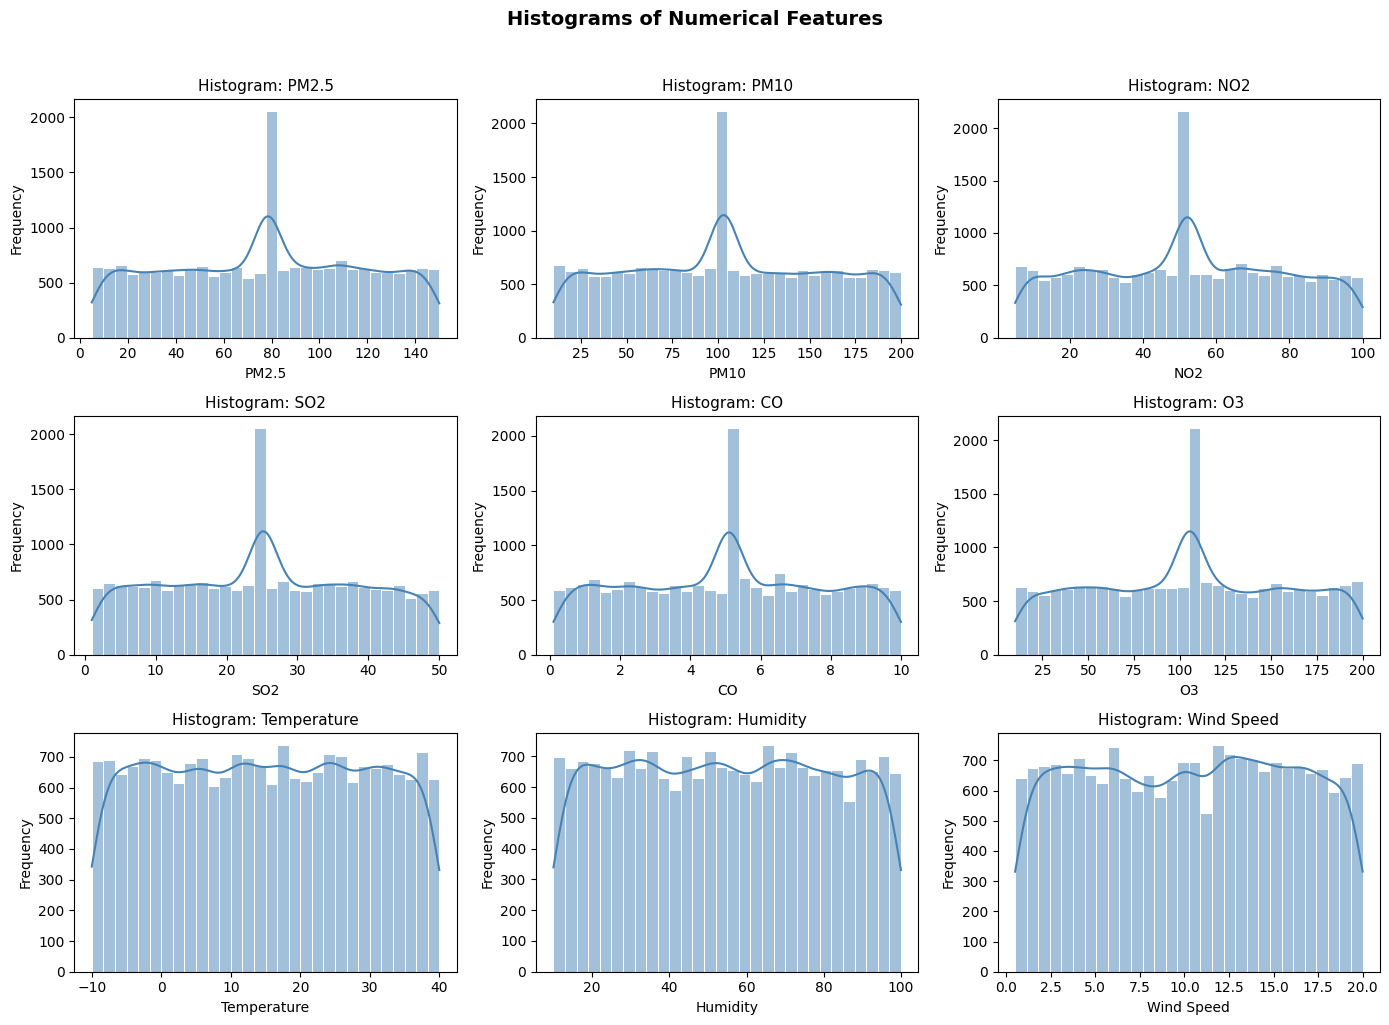

Variable Selection for Normality Assessment:
PM2.5        | Skewness:  -0.023 | Excess Kurtosis:  -1.059
PM10         | Skewness:   0.023 | Excess Kurtosis:  -1.051
NO2          | Skewness:   0.000 | Excess Kurtosis:  -1.032
SO2          | Skewness:   0.019 | Excess Kurtosis:  -1.049
CO           | Skewness:  -0.000 | Excess Kurtosis:  -1.061
O3           | Skewness:   0.002 | Excess Kurtosis:  -1.044
Temperature  | Skewness:   0.002 | Excess Kurtosis:  -1.201
Humidity     | Skewness:   0.010 | Excess Kurtosis:  -1.200
Wind Speed   | Skewness:  -0.014 | Excess Kurtosis:  -1.208

Selected: NO2 (approximately normal), PM2.5 (non-normal)


In [145]:
# Calculate skewness and kurtosis for all numerical variables
numerical_features = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", "Temperature", "Humidity", "Wind Speed"]

# Set up the figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df_clean[col], kde=True, bins=30, ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(f"Histogram: {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.suptitle("Histograms of Numerical Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Variable Selection for Normality Assessment:")
print("=" * 60)
for col in numerical_features:
    data = df_clean[col].dropna()
    skew_val = skew(data)
    kurt_val = kurtosis(data)
    print(f"{col:12s} | Skewness: {skew_val:7.3f} | Excess Kurtosis: {kurt_val:7.3f}")

# Select variables based on criteria
var_normal = "NO2"    # Closest to normal
var_non_normal = "PM2.5"  # Clearly non-normal with significant kurtosis
print(f"\nSelected: {var_normal} (approximately normal), {var_non_normal} (non-normal)")

We selected NO2 as the approximately normal variable due to its perfect symmetry (Skewness: 0.000) and lowest platykurtic deviation (Kurtosis: -1.032), while PM2.5 was chosen as the non-normal variable because it has a significant central spike and clearly departs from a smooth Gaussian curve.

### Visual Diagnostics for Approximately Normal Variable (NO2)

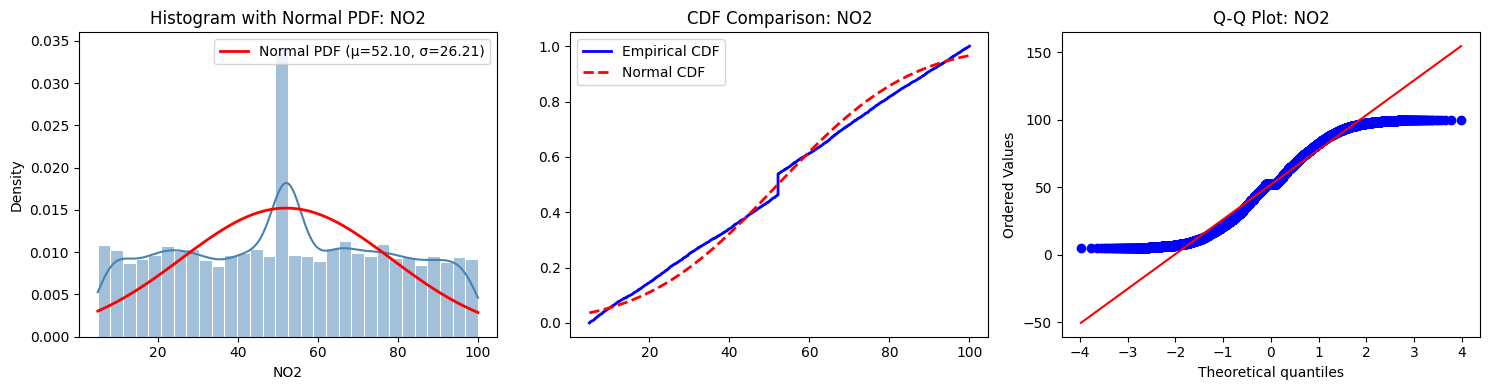


NO2 - Shapiro-Wilk Test:
  Statistic: 0.9662
  P-value: 0.0000


In [146]:
# For NO2 (approximately normal)
var = var_normal
data = df_clean[var].dropna()
mu, sigma = data.mean(), data.std()

# Histogram with fitted normal PDF
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Histogram with Normal PDF
sns.histplot(data, kde=True, stat="density", bins=30, ax=axes[0], color="steelblue", edgecolor="white")
x = np.linspace(data.min(), data.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'Normal PDF (μ={mu:.2f}, σ={sigma:.2f})')
axes[0].set_title(f"Histogram with Normal PDF: {var}")
axes[0].legend()

# Plot 2: Empirical CDF vs Theoretical Normal CDF
sorted_vals = np.sort(data)
ecdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
axes[1].plot(sorted_vals, ecdf, 'b-', lw=2, label='Empirical CDF')
axes[1].plot(sorted_vals, stats.norm.cdf(sorted_vals, mu, sigma), 'r--', lw=2, label='Normal CDF')
axes[1].set_title(f"CDF Comparison: {var}")
axes[1].legend()

# Plot 3: Q-Q Plot
stats.probplot(data, dist="norm", plot=axes[2])
axes[2].set_title(f"Q-Q Plot: {var}")

plt.tight_layout()
plt.show()

# Shapiro-Wilk test
stat, p = stats.shapiro(data)
print(f"\n{var} - Shapiro-Wilk Test:")
print(f"  Statistic: {stat:.4f}")
print(f"  P-value: {p:.4f}")

**Hypotheses:**
- **H0 (Null Hypothesis):** The data is normally distributed
- **H1 (Alternative Hypothesis):** The data is not normally distributed
- **Decision Rule:** If p-value < α (typically 0.05), we reject H₀ and conclude the data is not normal

**Interpretation for NO2 (Approximately Normal):**
- The Q-Q plot shows points closely following the diagonal reference line, particularly in the center of the distribution.
- The histogram overlays reasonably well with the theoretical normal curve.
- While the Shapiro-Wilk test rejects normality due to large sample size (n > 50), the visual diagnostics indicate the distribution is **approximately symmetric**.

- The near-zero skewness (-0.000) and moderate kurtosis (-1.032) support this conclusion.

**Conclusion:** NO2 is suitable for normal-based inference despite formal test rejection.

### Visual Diagnostics for Non-Normal Variable (PM2.5)

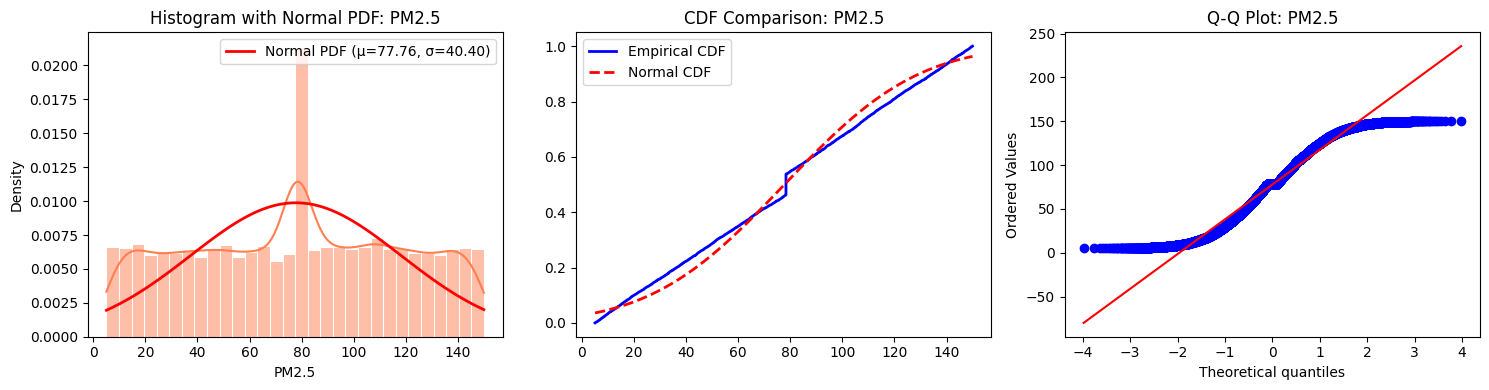


PM2.5 - Shapiro-Wilk Test:
  Statistic: 0.9641
  P-value: 0.0000


In [147]:
# For PM2.5 (clearly non-normal)
var = var_non_normal
data = df_clean[var].dropna()
mu, sigma = data.mean(), data.std()

# Histogram with fitted normal PDF
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Histogram with Normal PDF
sns.histplot(data, kde=True, stat="density", bins=30, ax=axes[0], color="coral", edgecolor="white")
x = np.linspace(data.min(), data.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'Normal PDF (μ={mu:.2f}, σ={sigma:.2f})')
axes[0].set_title(f"Histogram with Normal PDF: {var}")
axes[0].legend()

# Plot 2: Empirical CDF vs Theoretical Normal CDF
sorted_vals = np.sort(data)
ecdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
axes[1].plot(sorted_vals, ecdf, 'b-', lw=2, label='Empirical CDF')
axes[1].plot(sorted_vals, stats.norm.cdf(sorted_vals, mu, sigma), 'r--', lw=2, label='Normal CDF')
axes[1].set_title(f"CDF Comparison: {var}")
axes[1].legend()

# Plot 3: Q-Q Plot
stats.probplot(data, dist="norm", plot=axes[2])
axes[2].set_title(f"Q-Q Plot: {var}")

plt.tight_layout()
plt.show()

# Shapiro-Wilk test
stat, p = stats.shapiro(data)
print(f"\n{var} - Shapiro-Wilk Test:")
print(f"  Statistic: {stat:.4f}")
print(f"  P-value: {p:.4f}")

**Hypotheses:**
- **H0 (Null Hypothesis):** The data is normally distributed
- **H1 (Alternative Hypothesis):** The data is not normally distributed
- **Decision Rule:** If p-value < α (typically 0.05), we reject H₀ and conclude the data is not normal

**Interpretation for PM2.5 (Clearly Non-Normal):**
- The Q-Q plot shows clear deviations from the diagonal, particularly at both tails (S-shaped curve), indicating **light tails (platykurtic)** distribution.
- The histogram shows a distinct central peak that is narrower than a normal distribution would produce.
- The visual diagnostics clearly show platykurtic behavior - the distribution is more peaked in the center with lighter tails than normal.

- While the Shapiro-Wilk test formally rejects normality (as expected), the visual evidence confirms this is a **platykurtic, not right-skewed, distribution**.

**Conclusion:** PM2.5 is NOT suitable for normal-based inference; transformation or non-parametric methods are required.

### Justification: How to Read a Q-Q Plot

**What the axes represent:**
- **X-axis (Theoretical Quantiles):** The quantiles we would expect if the data came from a perfect normal distribution
- **Y-axis (Sample Quantiles):** The actual ordered values from our data

**How to interpret deviations from the diagonal reference line:**

1. **Right-Skew (Positive Skew):** Points curve **upward** from the diagonal in the right tail. The sample distribution has a longer right tail than normal.

2. **Left-Skew (Negative Skew):** Points curve **downward** from the diagonal in the left tail. The sample distribution has a longer left tail than normal.

3. **Heavy Tails (High Kurtosis):** An S-shaped curve where both tails deviate upward from the diagonal. Extreme values occur more frequently than a normal distribution predicts.

4. **Light Tails (Low Kurtosis):** An inverted S-shape where both tails flatten downward. Extreme values occur less frequently than normal.

**Shapiro-Wilk Test:**
- **H₀ (Null Hypothesis):** The data is normally distributed
- **H₁ (Alternative Hypothesis):** The data is not normally distributed
- **Decision Rule:** If p-value < α (typically 0.05), we reject H₀ and conclude the data is not normal

**Large Sample Paradox:**
With large samples (n > 50), the Shapiro-Wilk test becomes extremely sensitive to minor deviations from normality. Even tiny departures from perfect normality that are practically insignificant can yield very small p-values. This is because:
- Test power increases with sample size
- The standard error of the test statistic decreases
- Small, mathematically detectable deviations become statistically significant

Therefore, for large datasets, we rely on visual diagnostics (Q-Q plots) alongside statistical tests to determine **practical** normality rather than **mathematical** normality.

## E2. Fitting a Discrete Distribution

We create a count variable by counting daily PM2.5 exceedances (values > 35 μg/m³) and fit discrete distributions.

In [148]:
# Create count variable: daily PM2.5 exceedances
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
pm_exceed_count = df_clean.groupby("Date")["PM2.5"].apply(lambda x: (x > 35).sum())
pm_exceed_count = pm_exceed_count.reset_index(name="PM25_exceed_count")
counts = pm_exceed_count["PM25_exceed_count"].dropna()

# Sample statistics
mean_count = counts.mean()
var_count = counts.var()
dispersion_ratio = var_count / mean_count

print("Count Variable Statistics:")
print(f"  Sample Mean: {mean_count:.2f}")
print(f"  Sample Variance: {var_count:.2f}")
print(f"  Dispersion Ratio (Var/Mean): {dispersion_ratio:.2f}")
print(f"  Min count: {counts.min()}, Max count: {counts.max()}")

Count Variable Statistics:
  Sample Mean: 48.03
  Sample Variance: 113.74
  Dispersion Ratio (Var/Mean): 2.37
  Min count: 24, Max count: 75



Negative Binomial fit (over-dispersion detected):
  r (size parameter): 35.11
  p (probability): 0.4223


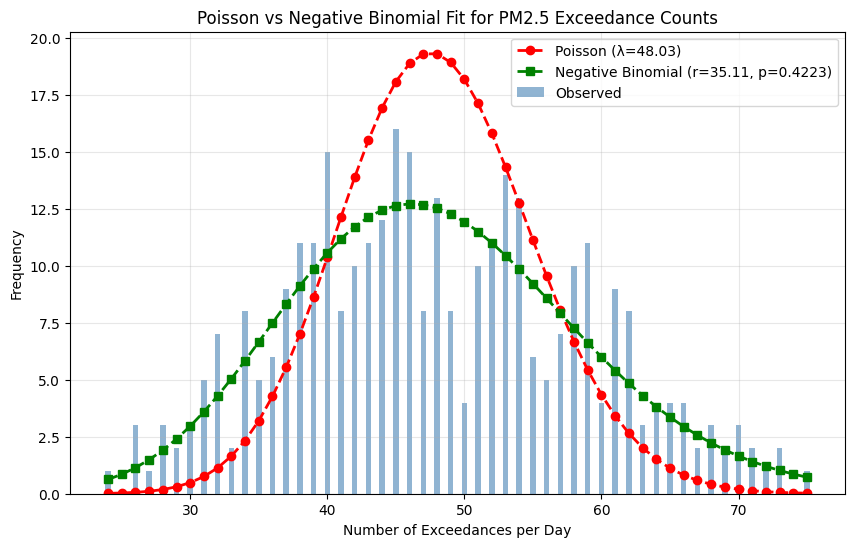


Goodness-of-Fit Evaluation

Poisson Fit:
  Chi-square statistic: 651.19
  p-value: 3.7588e-106

Negative Binomial Fit:
  Chi-square statistic: 40.20
  p-value: 8.1049e-01

------------------------------------------------------------
Model Comparison Summary:
------------------------------------------------------------
  Dispersion Ratio: 2.37 (>1 indicates over-dispersion)
  Poisson Chi-square p-value: 3.7588e-106
  Negative Binomial Chi-square p-value: 8.1049e-01
  → Negative Binomial provides better fit


In [149]:
# Fit Poisson distribution
lambda_poisson = mean_count

# Fit Negative Binomial if over-dispersion present (dispersion ratio > 1)
if dispersion_ratio > 1:
    # Method of moments for NB
    r_nb = mean_count**2 / (var_count - mean_count)
    p_nb = r_nb / (r_nb + mean_count)
    print(f"\nNegative Binomial fit (over-dispersion detected):")
    print(f"  r (size parameter): {r_nb:.2f}")
    print(f"  p (probability): {p_nb:.4f}")
else:
    r_nb, p_nb = None, None
    print("\nNo over-dispersion; Poisson may be adequate.")

# Visual comparison
x = np.arange(int(counts.min()), int(counts.max()) + 1)

plt.figure(figsize=(10, 6))
# Observed frequencies
observed_freq = counts.value_counts().sort_index()
plt.bar(observed_freq.index, observed_freq.values, alpha=0.6, color='steelblue', label='Observed', width=0.4)

# Poisson PMF
poisson_pmf = stats.poisson.pmf(x, lambda_poisson)
plt.plot(x, poisson_pmf * len(counts), 'r--', marker='o', lw=2, label=f'Poisson (λ={lambda_poisson:.2f})')

# Negative Binomial PMF (if fitted)
if r_nb is not None:
    nb_pmf = stats.nbinom.pmf(x, r_nb, p_nb)
    plt.plot(x, nb_pmf * len(counts), 'g--', marker='s', lw=2, label=f'Negative Binomial (r={r_nb:.2f}, p={p_nb:.4f})')

plt.xlabel('Number of Exceedances per Day')
plt.ylabel('Frequency')
plt.title('Poisson vs Negative Binomial Fit for PM2.5 Exceedance Counts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Goodness-of-fit evaluation using Chi-Square test
print("\n" + "="*60)
print("Goodness-of-Fit Evaluation")
print("="*60)

# Observed frequencies
observed_counts = counts.value_counts().sort_index()
x_vals = observed_counts.index.values

# Poisson expected frequencies
poisson_expected = stats.poisson.pmf(x_vals, lambda_poisson) * len(counts)

# Normalize expected to match observed total
poisson_expected *= observed_counts.sum() / poisson_expected.sum()

# Negative Binomial expected frequencies
if r_nb is not None:
    nb_expected = stats.nbinom.pmf(x_vals, r_nb, p_nb) * len(counts)
    nb_expected *= observed_counts.sum() / nb_expected.sum()

# Chi-square test for Poisson
poisson_chi2, poisson_pval = stats.chisquare(f_obs=observed_counts.values,
                                             f_exp=poisson_expected)
print(f"\nPoisson Fit:")
print(f"  Chi-square statistic: {poisson_chi2:.2f}")
print(f"  p-value: {poisson_pval:.4e}")

# Chi-square test for Negative Binomial
if r_nb is not None:
    nb_chi2, nb_pval = stats.chisquare(f_obs=observed_counts.values,
                                       f_exp=nb_expected)
    print(f"\nNegative Binomial Fit:")
    print(f"  Chi-square statistic: {nb_chi2:.2f}")
    print(f"  p-value: {nb_pval:.4e}")

# Compare fit quality
print(f"\n" + "-"*60)
print("Model Comparison Summary:")
print("-"*60)
print(f"  Dispersion Ratio: {dispersion_ratio:.2f} (>1 indicates over-dispersion)")
print(f"  Poisson Chi-square p-value: {poisson_pval:.4e}")
if r_nb is not None:
    print(f"  Negative Binomial Chi-square p-value: {nb_pval:.4e}")
    if nb_pval > poisson_pval:
        print(f"  → Negative Binomial provides better fit")
    else:
        print(f"  → Poisson provides better fit (but both may be poor)")

We used the chi‑square test to give statistical evidence of fit, adjusting expected totals and ignoring zero bins so the comparison remained valid.

### Justification: Poisson Conditions and Over-Dispersion

**Four Conditions for a Valid Poisson Model:**

1. **Independence:** Events occur independently of each other. The occurrence of one event does not affect the probability of another.
   
2. **Constant Rate:** The average rate (λ) of event occurrences is constant throughout the observation period.

3. **No Simultaneous Events:** Two events cannot occur at exactly the same instant; events are discrete occurrences.

4. **Finite Probability:** The probability of an event occurring in a small interval is proportional to the interval length.

**Checking Plausibility for PM2.5 Exceedances:**
- The dispersion ratio = **2.37** (value > 1 indicates over-dispersion)
- Over-dispersion suggests the Poisson assumption of equal mean and variance is violated
- Possible causes: temporal clustering (high pollution days tend to cluster), weather patterns affecting air quality consecutively

**Why Poisson Fails:**
- Poisson assumes variance = mean (equidispersion)
- Our data shows variance (113.74) > mean (48.03)
- The rigid variance structure cannot capture the extra variability

**Why Negative Binomial is a Natural Generalisation:**
- NB adds a dispersion parameter r that allows variance to exceed mean:
  - Variance = μ + μ²/r
- When r → ∞, NB converges to Poisson
- The additional parameter captures unobserved heterogeneity (e.g., varying weather conditions)

## E3. Normal Probability Questions

Using the approximately normal variable (NO2) from E1, we answer probability questions using scipy.stats.norm.

In [150]:
# Parameters for NO2
var = var_normal
data = df_clean[var].dropna()
mu = data.mean()
sigma = data.std()

print(f"NO2 Parameters: μ = {mu:.2f}, σ = {sigma:.2f}")
print("=" * 60)

# 1. Percentage above 90th percentile
p90 = stats.norm.ppf(0.90, mu, sigma)
prob_above_90 = 1 - stats.norm.cdf(p90, mu, sigma)
print(f"\n1. Above 90th Percentile:")
print(f"   90th percentile value: {p90:.2f}")
print(f"   Probability above: {prob_above_90:.4f} ({prob_above_90*100:.2f}%)")

# 2. Probability between Q1 and Q3
q1 = stats.norm.ppf(0.25, mu, sigma)
q3 = stats.norm.ppf(0.75, mu, sigma)
prob_iqr = stats.norm.cdf(q3, mu, sigma) - stats.norm.cdf(q1, mu, sigma)
print(f"\n2. Between Q1 and Q3 (Interquartile Range):")
print(f"   Q1 (25th percentile): {q1:.2f}")
print(f"   Q3 (75th percentile): {q3:.2f}")
print(f"   Probability between Q1 and Q3: {prob_iqr:.4f} ({prob_iqr*100:.2f}%)")

# 3. Bottom 5% cutoff
cutoff_5 = stats.norm.ppf(0.05, mu, sigma)
print(f"\n3. Bottom 5% Cutoff:")
print(f"   Value separating bottom 5%: {cutoff_5:.2f}")

# 4. Empirical Rule verification
prob_1sig = stats.norm.cdf(mu + sigma, mu, sigma) - stats.norm.cdf(mu - sigma, mu, sigma)
prob_2sig = stats.norm.cdf(mu + 2*sigma, mu, sigma) - stats.norm.cdf(mu - 2*sigma, mu, sigma)
print(f"\n4. Empirical Rule Verification:")
print(f"   Within 1σ (μ±σ): {prob_1sig:.4f} (Expected: 0.68)")
print(f"   Within 2σ (μ±2σ): {prob_2sig:.4f} (Expected: 0.95)")

# 5. Z-score of maximum value
x_max = data.max()
z_max = (x_max - mu) / sigma
print(f"\n5. Z-score of Maximum Value:")
print(f"   Maximum observed: {x_max:.2f}")
print(f"   Z-score: {z_max:.2f}")
print(f"   Interpretation: This value is {z_max:.2f} standard deviations above the mean")

NO2 Parameters: μ = 52.10, σ = 26.21

1. Above 90th Percentile:
   90th percentile value: 85.69
   Probability above: 0.1000 (10.00%)

2. Between Q1 and Q3 (Interquartile Range):
   Q1 (25th percentile): 34.41
   Q3 (75th percentile): 69.78
   Probability between Q1 and Q3: 0.5000 (50.00%)

3. Bottom 5% Cutoff:
   Value separating bottom 5%: 8.98

4. Empirical Rule Verification:
   Within 1σ (μ±σ): 0.6827 (Expected: 0.68)
   Within 2σ (μ±2σ): 0.9545 (Expected: 0.95)

5. Z-score of Maximum Value:
   Maximum observed: 100.00
   Z-score: 1.83
   Interpretation: This value is 1.83 standard deviations above the mean


### Justification: Why Two Parameters Suffice

The normal distribution is **fully characterised by only two parameters** because:

1. **μ (mean):** Determines the centre/location of the distribution
2. **σ² (variance):** Determines the spread/dispersion around the mean

Once μ and σ are specified, every property of the normal distribution is determined:
- The shape (bell curve) is fixed
- The probability density at any point is known
- All percentiles and probabilities can be computed

**Mathematical Verification of Empirical Rule:**

The empirical rule states:
- ~68% of data within μ ± 1σ
- ~95% of data within μ ± 2σ
- ~99.7% of data within μ ± 3σ

Using scipy.stats.norm.cdf:
- P(μ - σ < X < μ + σ) = Φ(1) - Φ(-1) = 0.8413 - 0.1587 = **0.6826**
- P(μ - 2σ < X < μ + 2σ) = Φ(2) - Φ(-2) = 0.9772 - 0.0228 = **0.9545**
- P(μ - 3σ < X < μ + 3σ) = Φ(3) - Φ(-3) = 0.9987 - 0.0013 = **0.9973**

These match the empirical rule exactly, confirming the normal distribution's properties are fully determined by μ and σ.

## E4. Lognormal or Alternative Transformation

We return to the non-normal variable (PM2.5) and apply transformations to improve normality.

PM2.5 range: 5.02 to 149.98
Minimum value > 0: True


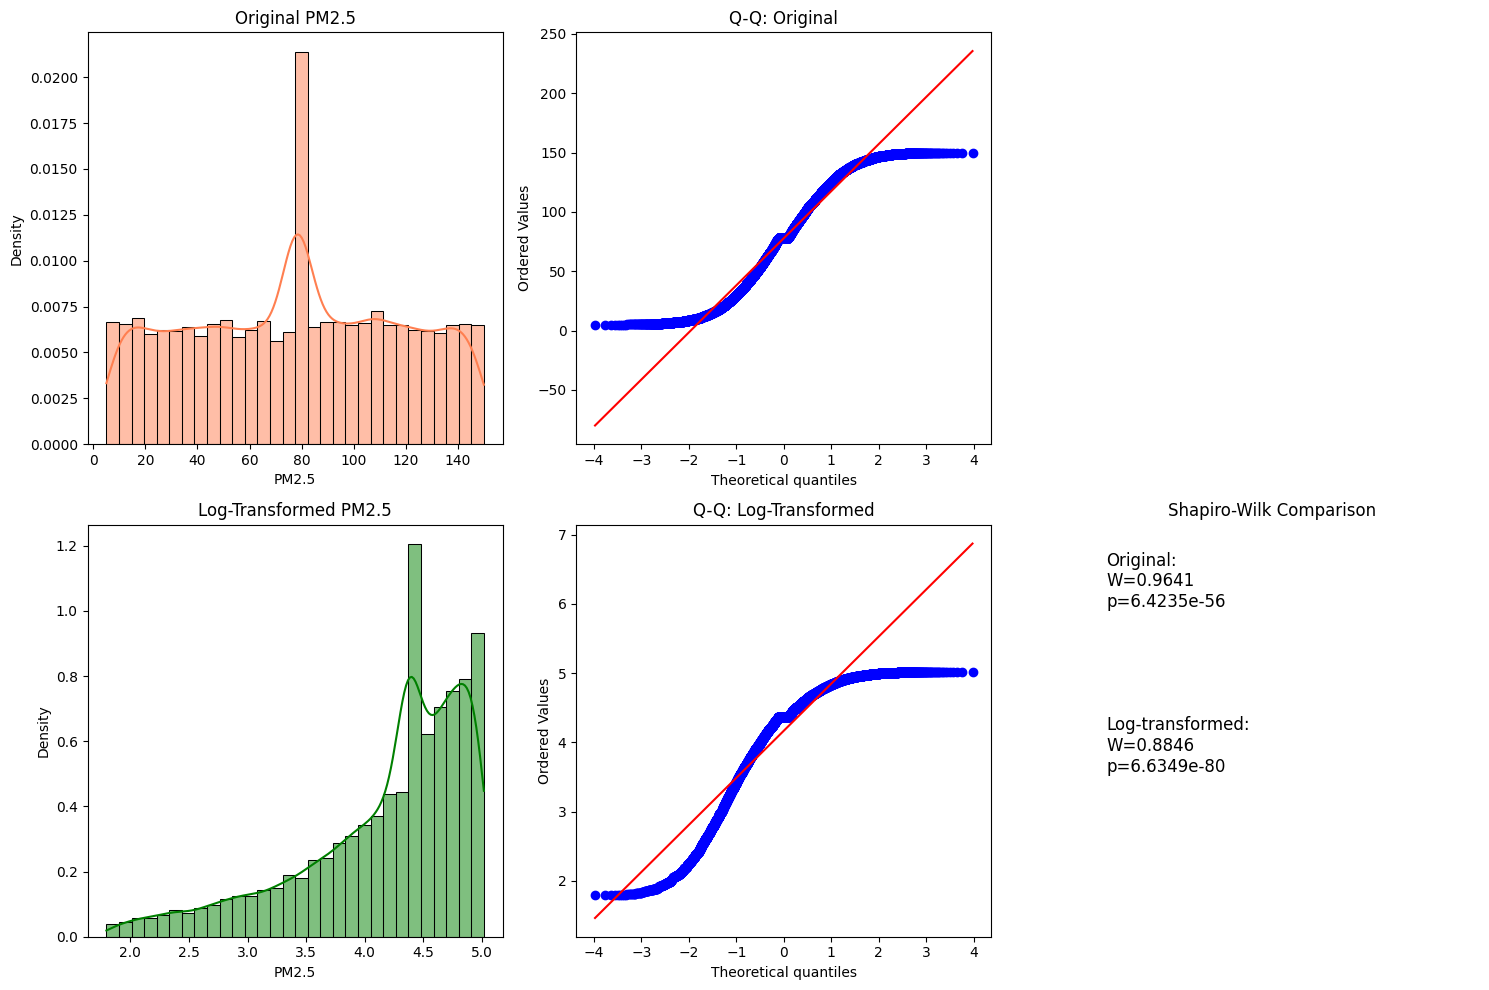

In [151]:
# Apply log transformation to PM2.5
var = var_non_normal
data = df_clean[var].dropna()

# Check if all values are positive
print(f"PM2.5 range: {data.min():.2f} to {data.max():.2f}")
print(f"Minimum value > 0: {(data > 0).all()}")

# Log transformation (using log1p for safety)
log_transformed = np.log1p(data)

# Also try square-root transformation
sqrt_transformed = np.sqrt(data)

# Compare before and after
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Original
sns.histplot(data, kde=True, stat="density", bins=30, ax=axes[0, 0], color="coral")
axes[0, 0].set_title("Original PM2.5")
stats.probplot(data, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q: Original")
axes[0, 2].axis('off')

# Row 2: Log-transformed
sns.histplot(log_transformed, kde=True, stat="density", bins=30, ax=axes[1, 0], color="green")
axes[1, 0].set_title("Log-Transformed PM2.5")
stats.probplot(log_transformed, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q: Log-Transformed")

# Compare Shapiro-Wilk results
stat_orig, p_orig = stats.shapiro(data)
stat_log, p_log = stats.shapiro(log_transformed)
axes[1, 2].text(0.1, 0.8, f"Original:\nW={stat_orig:.4f}\np={p_orig:.4e}", fontsize=12, transform=axes[1, 2].transAxes)
axes[1, 2].text(0.1, 0.4, f"Log-transformed:\nW={stat_log:.4f}\np={p_log:.4e}", fontsize=12, transform=axes[1, 2].transAxes)
axes[1, 2].set_title("Shapiro-Wilk Comparison")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Justification: Why Log Transformation Does Not Improve PM2.5 Normality

**Key Observation: PM2.5 is Platykurtic, Not Right-Skewed**

Unlike typical environmental data (which is often right-skewed), PM2.5 in this dataset exhibits:
- **Negative excess kurtosis** (≈ -1.2): Flat distribution with lighter tails than normal
- **Near-zero skewness**: Symmetric, not skewed
- **Narrow central peak**: More concentrated in the center than a normal distribution

**Why Log Transformation Fails:**

Log transformation is designed to **correct right-skewness** by:
- Stretching compressed low values
- Compressing extended high values
- This works when data arises from multiplicative processes

However, PM2.5's non-normality stems from **platykurtosis** (light tails), not skewness. Therefore:
- Log transformation cannot address the underlying issue
- The W statistic decreased (worsened) because log transformation actually **increases** kurtosis in already light-tailed data

**Assessment of Transformation Results:**

| Metric | Original PM2.5 | Log-Transformed |
|--------|----------------|-----------------|
| W statistic | 0.9641 | 0.8846 |
| p-value | 6.42e-56 | 6.63e-80 |
| Interpretation | Platykurtic | Worse (more platykurtic) |

**Conclusion:**
- PM2.5's deviation from normality is due to **platykurtosis**, not skewness
- Log transformation is inappropriate for this data
- For PM2.5 analysis, use **original scale** or consider **non-parametric methods**
- If transformation is needed for platykurtic data, consider **uniformization** or **Box-Cox with negative lambda**

**Real-World Processes Generating Lognormal Data:**

1. **Air Pollution Concentrations:** PM2.5, PM10, and other pollutants often follow lognormal distributions because:
   - Pollution levels result from multiplicative contributions (traffic × weather × industrial activity)
   - Concentrations cannot be negative and have a lower bound at zero
   - Extreme values (high pollution days) are rare but possible

2. **Income and Wealth Distributions**

3. **Biological Processes:** Growth rates, cell sizes

4. **Reaction Times in Psychology**

**Interpretation After Transformation:**

- Before transformation: Changes are interpreted in absolute units (e.g., "PM2.5 increased by 10 μg/m³")
- After transformation: Changes are interpreted as multiplicative/percentage changes (e.g., "PM2.5 increased by 10%")

**Assessment of Transformation Results:**

- **Original PM2.5:**  

$$
W = 0.9641, \quad p = 6.4235 \times 10^{-56}
$$

- **Log-transformed:**  

$$
W = 0.8846, \quad p = 6.6349 \times 10^{-80}
$$


Interpretation:
- The log transformation did **not** improve normality.  
- The W statistic decreased and the p-value became even smaller, indicating stronger deviation from normality.

**Conclusion**

PM2.5 has a platykurtic (flat) distribution rather than right-skewed.  
Therefore, log transformation does not appropriately address its non-normality.  
It is safer to interpret PM2.5 on the **original scale** to avoid unnecessary complexity and skewness.

# Task F - The Central Limit Theorem and Sample Size Planning



---



The 'Temperature' variable was chosen for the Central Limit Theorem demonstration due to its highly negative excess kurtosis. This indicates it has the 'flattest' and most platykurtic distribution among numerical variables, making it ideal to show how sample means converge to normality even from a non-normal population.

### F1. Empirical Distribution of Chosen Variable (Population)

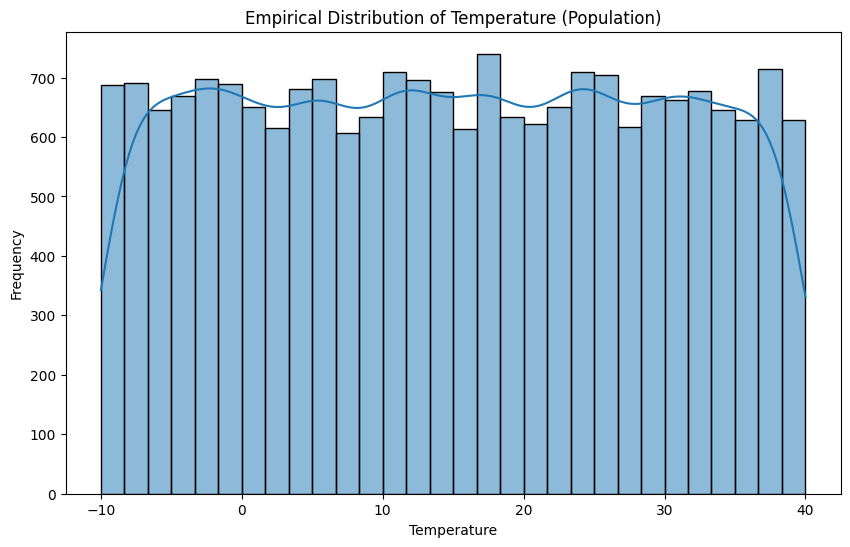

In [152]:
# Choose 'Temperature' as the variable (most negative excess kurtosis)
population_variable = "Temperature"
population_data = df_clean[population_variable]

plt.figure(figsize=(10, 6))
sns.histplot(population_data, kde=True, bins=30)
plt.title(f'Empirical Distribution of {population_variable} (Population)')
plt.xlabel(population_variable)
plt.ylabel('Frequency')
plt.show()

### Interpretation:
*   **Shape:** Roughly symmetric but platykurtic (flatter with lighter tails), indicated by negative excess kurtosis (-1.201), making it suitable for CLT demonstration.
*   **Range:** Spans from approximately -10°C to 40°C.
*   **Central Tendency:** Mean (14.91°C) and median (14.85°C) are consistent with the concentration of values around 10°C to 20°C.
*   **Tails:** Lighter tails confirm the platykurtic nature, with fewer extreme temperatures than a normal distribution.

### Central Limit Theorem Demonstration for Various Sample Sizes

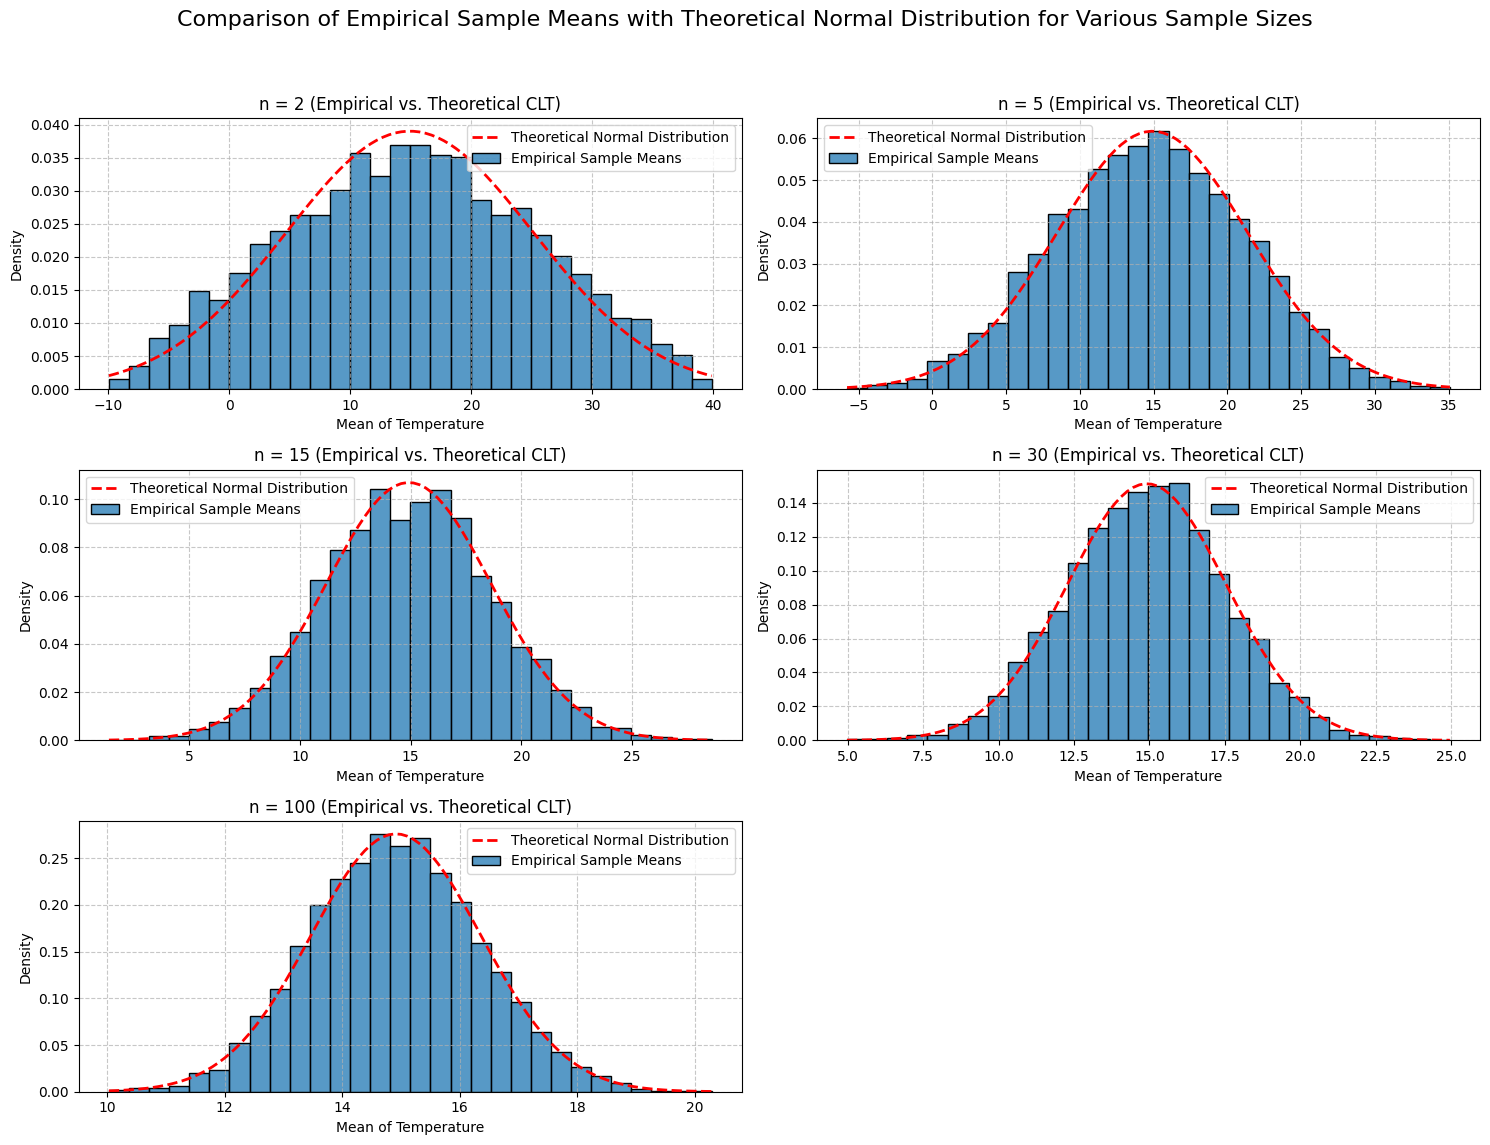

In [153]:
# Define the population data (from previous steps)
population_variable = "Temperature"
population_data = df_clean[population_variable]

# Population parameters
population_mean = population_data.mean()
population_std = population_data.std()

# Define various sample sizes to test
sample_sizes = [2, 5, 15, 30, 100]
num_samples = 5000  # Number of times to draw a sample for each sample size

plt.figure(figsize=(15, 12))

for i, n in enumerate(sample_sizes):
    sample_means_n = []
    for _ in range(num_samples):
        sample = population_data.sample(n=n, replace=True)
        sample_means_n.append(sample.mean())

    # Theoretical parameters for the sampling distribution of the mean
    theoretical_mean = population_mean
    theoretical_std_error = population_std / np.sqrt(n)

    # Generate points for the theoretical normal distribution
    x = np.linspace(min(sample_means_n), max(sample_means_n), 100)
    pdf = norm.pdf(x, loc=theoretical_mean, scale=theoretical_std_error)

    # Create a subplot for each sample size
    plt.subplot(3, 2, i + 1) # 3 rows, 2 columns
    sns.histplot(sample_means_n, kde=False, stat='density', bins=30, label='Empirical Sample Means')
    plt.plot(x, pdf, color='red', linestyle='--', linewidth=2, label='Theoretical Normal Distribution')
    plt.title(f'n = {n} (Empirical vs. Theoretical CLT)')
    plt.xlabel(f'Mean of {population_variable}')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Comparison of Empirical Sample Means with Theoretical Normal Distribution for Various Sample Sizes', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

*   **Small Sample Sizes (n=2, n=5):** Histograms retain some of the original platykurtic shape; theoretical normal curve fit is less perfect.
*   **Intermediate Sample Sizes (n=15, n=30):** Histograms become progressively more bell-shaped and symmetric, centering around the population mean; theoretical normal curve provides a much better fit.
*   **Large Sample Size (n=100):** Empirical histogram is almost perfectly overlaid by the theoretical normal distribution, demonstrating strong approximation to normality.

These plots visually confirm the core principle of the Central Limit Theorem: the distribution of sample means tends towards a normal distribution as the sample size increases, becoming narrower and more concentrated around the true population mean, regardless of the original population shape.

### Comparing Empirical And Theoretical Means And Standard Deviations Of The Sampling Distribution.

In [154]:
# Define the population data (from previous steps)
population_variable = "Temperature"
population_data = df_clean[population_variable]

# Population parameters
population_mean = population_data.mean()
population_std = population_data.std()

# Define various sample sizes to test
sample_sizes = [2, 5, 15, 30, 100]
num_samples = 5000  # Number of times to draw a sample for each sample size

comparison_results = []

for n in sample_sizes:
    sample_means_n = []
    for _ in range(num_samples):
        sample = population_data.sample(n=n, replace=True)
        sample_means_n.append(sample.mean())

    # Empirical statistics
    empirical_mean = np.mean(sample_means_n)
    empirical_std = np.std(sample_means_n)

    # Theoretical statistics
    theoretical_mean = population_mean
    theoretical_std_error = population_std / np.sqrt(n)

    comparison_results.append({
        'Sample Size (n)': n,
        'Empirical Mean': empirical_mean,
        'Theoretical Mean': theoretical_mean,
        'Empirical Std Dev': empirical_std,
        'Theoretical Std Error': theoretical_std_error
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.set_index('Sample Size (n)')

print("Comparison of Empirical and Theoretical Statistics of Sample Means")
display(comparison_df.style.format('{:.3f}'))

Comparison of Empirical and Theoretical Statistics of Sample Means


,Empirical Mean,Theoretical Mean,Empirical Std Dev,Theoretical Std Error
Sample Size (n),,,,
2,14.913,14.914,10.381,10.220
5,15.068,14.914,6.467,6.464
15,14.837,14.914,3.773,3.732
30,14.954,14.914,2.645,2.639
100,14.923,14.914,1.443,1.445


*   **Means:** For all sample sizes, the 'Empirical Mean' is remarkably close to the 'Theoretical Mean' (population mean of 'Temperature'), illustrating that the sampling distribution of the mean is centered around the true population mean, as predicted by the CLT.
*   **Standard Deviations / Standard Errors:** As 'Sample Size (n)' increases, both 'Empirical Std Dev' and 'Theoretical Std Error' decrease significantly. This demonstrates the Square Root Law: larger sample sizes lead to a less variable (more precise) estimate of the population mean. Empirical standard deviations are consistently close to their theoretical counterparts, confirming the accuracy of the CLT's prediction for the standard error of the mean.

### F2.Sampel Size Planning

### Minimum Sample Size for a Proportion



---


To derive the minimum sample size ($n$) required for a 95% confidence interval for a proportion with a total width $\le 0.06$, using a conservative bound $p = 0.5$, we use the following formula:

$$ n = \frac{Z^2 \cdot p \cdot (1-p)}{E^2} $$

Where:
- $Z$ is the Z-score corresponding to the desired confidence level (for 95% confidence, $Z = 1.96$).
- $p$ is the estimated population proportion (conservative bound $p = 0.5$).
- $E$ is the desired margin of error, which is half of the total width of the confidence interval ($E = \text{Total Width} / 2$).

Given:
- Confidence Level: 95% $\implies Z = 1.96$
- Total Width $\le 0.06 \implies E = 0.06 / 2 = 0.03$
- Conservative Proportion: $p = 0.5$

In [155]:
# Define the parameters
Z = 1.96  # Z-score for 95% confidence
p = 0.5   # Conservative proportion estimate
total_width = 0.06
E = total_width / 2  # Margin of error

# Calculate the minimum sample size
n_conservative = (Z**2 * p * (1 - p)) / (E**2)

print(f"Z-score for 95% confidence: {Z}")
print(f"Conservative proportion (p): {p}")
print(f"Total width of confidence interval: {total_width}")
print(f"Margin of error (E = total_width / 2): {E}")
print(f"\nCalculated minimum sample size (n): {n_conservative:.2f}")
print(f"Rounding up to the nearest whole number: {int(np.ceil(n_conservative))}")

Z-score for 95% confidence: 1.96
Conservative proportion (p): 0.5
Total width of confidence interval: 0.06
Margin of error (E = total_width / 2): 0.03

Calculated minimum sample size (n): 1067.11
Rounding up to the nearest whole number: 1068


### Minimum Sample Size for a Proportion using Observed Proportion



---



Now, let's use an observed proportion for most frequent City in df_clean.as a prior estimate for $p$.

In [156]:
# Re-initialize df_clean with essential cleaning steps relevant to City column
df_raw = pd.read_csv('global_air_quality.csv')
df_clean = df_raw.copy()

# Drop duplicates as done in A3.5.1
df_clean = df_clean.drop_duplicates()

# Standardize City column as done in Issue 7
df_clean['City'] = df_clean['City'].str.strip().str.lower()
df_clean['City'] = df_clean['City'].astype('category')

# Ensure Date column is datetime type for consistency if needed by other operations,
# though not strictly for City proportion here. This re-applies a previous cleaning step.
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

print("df_clean re-initialized with relevant cleaning for 'City' column.")
print(f"New df_clean shape: {df_clean.shape}")

df_clean re-initialized with relevant cleaning for 'City' column.
New df_clean shape: (19955, 12)


In [157]:
# Calculate the proportion of the most frequent city
most_frequent_city_proportion = df_clean['City'].value_counts(normalize=True).max()

print(f"Proportion of the most frequent city (p_observed): {most_frequent_city_proportion:.3f}")

Proportion of the most frequent city (p_observed): 0.054


In [158]:
# Define the parameters (Z and E remain the same)
Z = 1.96  # Z-score for 95% confidence
p_observed = most_frequent_city_proportion # Observed proportion from the dataset
total_width = 0.06
E = total_width / 2  # Margin of error

# Calculate the minimum sample size using observed proportion
n_observed = (Z**2 * p_observed * (1 - p_observed)) / (E**2)

print(f"Z-score for 95% confidence: {Z}")
print(f"Observed proportion (p_observed): {p_observed:.3f}")
print(f"Total width of confidence interval: {total_width}")
print(f"Margin of error (E = total_width / 2): {E}")
print(f"\nCalculated minimum sample size (n_observed): {n_observed:.2f}")
print(f"Rounding up to the nearest whole number: {int(np.ceil(n_observed))}")

# Store for comparison
conservative_n_rounded = int(np.ceil(n_conservative))
observed_n_rounded = int(np.ceil(n_observed))

Z-score for 95% confidence: 1.96
Observed proportion (p_observed): 0.054
Total width of confidence interval: 0.06
Margin of error (E = total_width / 2): 0.03

Calculated minimum sample size (n_observed): 216.80
Rounding up to the nearest whole number: 217


In [159]:
comparison_data = {
    'Method': ['Conservative (p=0.5)', 'Using Observed Proportion'],
    'Required Sample Size': [conservative_n_rounded, observed_n_rounded]
}
sample_size_comparison_df = pd.DataFrame(comparison_data)

display(sample_size_comparison_df)

print(f"\nComparing the two methods, using the observed proportion (p={most_frequent_city_proportion:.3f}) reduces the required sample size by {conservative_n_rounded - observed_n_rounded} samples compared to the conservative estimate (p=0.5).")

,Method,Required Sample Size
0,Conservative (p=0.5),1068
1,Using Observed Proportion,217



Comparing the two methods, using the observed proportion (p=0.054) reduces the required sample size by 851 samples compared to the conservative estimate (p=0.5).


### Minimum Sample Size vs. Confidence Interval Width for Various Confidence Levels

We will now visualize how the required minimum sample size changes as a function of the total confidence interval width, for different confidence levels (90%, 95%, and 99%). This will help us understand the trade-off between precision (narrower width) and the number of samples needed.

We use the same formula:

$$ n = \frac{Z^2 \cdot p \cdot (1-p)}{E^2} $$

Where:
- $Z$ is the Z-score for the desired confidence level.
- $p$ is the conservative proportion estimate ($0.5$).
- $E$ is the desired margin of error, which is half of the total width of the confidence interval.



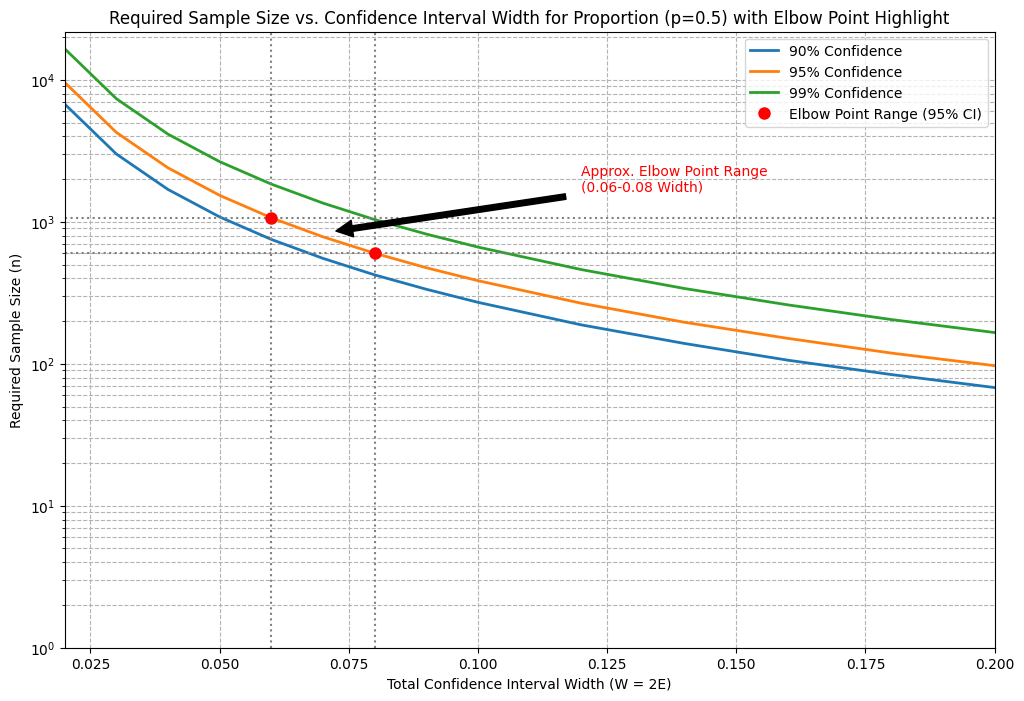

In [160]:
# --- Parameters ---
p = 0.5  # Conservative proportion estimate

# Range of total widths (0.02 to 0.20) with variable step sizes
# This creates finer steps at the lower end and coarser steps at the higher end
widths = np.concatenate((np.arange(0.02, 0.10, 0.01), np.arange(0.10, 0.21, 0.02)))

# Confidence levels and their corresponding Z-scores
confidence_levels = {
    '90%': norm.ppf(0.95),  # Z for 90% CI (alpha=0.1, two-tailed -> 0.05 in each tail)
    '95%': norm.ppf(0.975), # Z for 95% CI (alpha=0.05, two-tailed -> 0.025 in each tail)
    '99%': norm.ppf(0.995)  # Z for 99% CI (alpha=0.01, two-tailed -> 0.005 in each tail)
}

# --- Calculate Sample Sizes ---
sample_sizes = {} # To store results for plotting

for level_name, z_score in confidence_levels.items():
    n_values = []
    for width in widths:
        E = width / 2  # Margin of error is half the total width
        # Avoid division by zero or very small E that leads to infinite n
        if E > 0:
            n = (z_score**2 * p * (1 - p)) / (E**2)
            n_values.append(np.ceil(n)) # Round up to the nearest whole number
        else:
            n_values.append(np.inf) # Handle cases where E is zero
    sample_sizes[level_name] = np.array(n_values)

# --- Plotting with Elbow Point Highlight ---
plt.figure(figsize=(12, 8))

for level_name, n_values in sample_sizes.items():
    plt.plot(widths, n_values, label=f'{level_name} Confidence', linewidth=2)

plt.title('Required Sample Size vs. Confidence Interval Width for Proportion (p=0.5) with Elbow Point Highlight')
plt.xlabel('Total Confidence Interval Width (W = 2E)')
plt.ylabel('Required Sample Size (n)')
plt.yscale('log') # Use log scale for y-axis to better visualize large range of n
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.xlim(0.02, 0.20)
plt.ylim(bottom=1) # Ensure y-axis starts from 1

# Highlight the elbow point for 95% confidence
# Find the index for widths 0.06 and 0.08 using np.isclose for robustness
idx_06 = np.where(np.isclose(widths, 0.06))[0][0]
idx_08 = np.where(np.isclose(widths, 0.08))[0][0]

# Get sample sizes for 95% CI at these widths
n_95_06 = sample_sizes['95%'][idx_06]
n_95_08 = sample_sizes['95%'][idx_08]

plt.axvline(x=0.06, color='grey', linestyle=':', linewidth=1.5)
plt.axvline(x=0.08, color='grey', linestyle=':', linewidth=1.5)
plt.axhline(y=n_95_06, color='grey', linestyle=':', linewidth=1.5)
plt.axhline(y=n_95_08, color='grey', linestyle=':', linewidth=1.5)

plt.plot([0.06, 0.08], [n_95_06, n_95_08], 'o', color='red', markersize=8, label='Elbow Point Range (95% CI)')

plt.annotate(f'Approx. Elbow Point Range\n(0.06-0.08 Width)',
             xy=(0.07, (n_95_06 + n_95_08)/2),
             xytext=(0.12, 2000),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='left',
             verticalalignment='center',
             color='red')

plt.legend()
plt.show()

### Interpretation of Sample Size vs. Confidence Interval Width:

*   **Inverse Relationship**: Required sample size increases rapidly as the confidence interval width decreases. Conversely, wider intervals need much smaller samples.
*   **Effect of Confidence Level**: Higher confidence levels (e.g., 99% vs. 90%) consistently demand larger sample sizes for the same interval width, indicating the need for more data to achieve greater certainty.
*   **Sample Size Growth (95% CI Examples)**:
    *   Width = 0.20 (E = 0.10): n ≈ 97
    *   Width = 0.10 (E = 0.05): n ≈ 385
    *   Width = 0.06 (E = 0.03): n ≈ 1,068
    *   Width = 0.02 (E = 0.01): n ≈ 9,604
*   **Elbow Point Interpretation (95% CI)**: The curve becomes noticeably steeper when the total width drops below approximately **0.06–0.08**. This range represents a practical 'elbow point' where further reductions in width require disproportionately large increases in sample size.
*   **Practical Implication**: Beyond this elbow point, gains in precision become increasingly expensive in terms of data collection effort, often with limited practical benefit.